In [12]:
# ============================================================================
# Updated ELIXIR-UK RAG System for v3 Optimized Data
# ============================================================================

import numpy as np
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModel
import faiss
from collections import defaultdict, Counter
import json
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

class OptimizedElixirRAG:
    """
    RAG system optimized for v3 cleaned data with proper institutions and affiliations.
    """

    def __init__(self,
                 v3_data_path="/content/drive/MyDrive/outputs/seeds_approach/seeds_clean_outputs_v3_optimized/seeds_clean_full_v3.parquet",
                 embeddings_path="/content/drive/MyDrive/outputs/seeds_approach/seeds_biobert_embeddings_outputs/seeds_embeddings.npy",
                 faiss_path="/content/drive/MyDrive/outputs/seeds_approach/seeds_biobert_embeddings_outputs/seeds_faiss.index",
                 themes_path="/content/drive/MyDrive/outputs/seeds_approach/seeds_theme_rebuild_and_tag_outputs/seeds_with_themes_diagnosed_v2.parquet"):
        """Initialize with v3 optimized data."""

        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print(f"Using device: {self.device}")

        # Setup BioBERT
        self._setup_biobert()

        # Load v3 optimized data
        self._load_v3_data(v3_data_path, embeddings_path, faiss_path, themes_path)

        # Build enhanced indices
        self._build_enhanced_indices()

        print("✅ Optimized RAG system ready!")

    def _setup_biobert(self):
        """Setup BioBERT model."""
        print("Loading BioBERT...")
        model_name = "dmis-lab/biobert-v1.1"
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModel.from_pretrained(model_name)
        self.model.to(self.device)
        self.model.eval()

    def _load_v3_data(self, v3_data_path, embeddings_path, faiss_path, themes_path):
        """Load v3 optimized data."""
        print("Loading v3 optimized data...")

        # Load v3 data with proper institutions
        self.papers_df = pd.read_parquet(v3_data_path)
        print(f"   Loaded {len(self.papers_df):,} papers with institution data")

        # Load embeddings and FAISS index
        self.embeddings = np.load(embeddings_path).astype("float32")
        self.faiss_index = faiss.read_index(faiss_path)
        print(f"   Loaded embeddings: {self.embeddings.shape}")

        # Load themes data and merge
        try:
            themes_df = pd.read_parquet(themes_path)
            # Convert numpy arrays to lists if needed
            if 'themes_pred' in themes_df.columns:
                themes_df['themes_pred'] = themes_df['themes_pred'].apply(
                    lambda x: x.tolist() if isinstance(x, np.ndarray) else (x if isinstance(x, list) else [])
                )

            # Merge themes with papers (inner join to ensure alignment)
            self.papers_with_themes = self.papers_df.merge(
                themes_df[['pmid', 'themes_pred', 'themes_score']],
                on='pmid',
                how='inner'
            )
            print(f"   Merged themes: {len(self.papers_with_themes):,} papers with themes")

        except Exception as e:
            print(f"   Warning: Could not load themes data: {e}")
            self.papers_with_themes = self.papers_df.copy()
            self.papers_with_themes['themes_pred'] = [[] for _ in range(len(self.papers_with_themes))]

    def _build_enhanced_indices(self):
        """Build enhanced search indices using v3 data."""
        print("Building enhanced search indices...")

        # Theme indices
        self.theme_to_papers = defaultdict(list)
        self.paper_to_themes = {}

        for idx, row in self.papers_with_themes.iterrows():
            pmid = row['pmid']
            themes = row.get('themes_pred', [])

            if not isinstance(themes, list):
                themes = []

            self.paper_to_themes[pmid] = themes
            for theme in themes:
                self.theme_to_papers[theme].append(idx)

        # Institution indices (using v3 normalized institutions)
        self.institution_to_papers = defaultdict(list)

        for idx, row in self.papers_with_themes.iterrows():
            institutions = row.get('institutions', [])
            if isinstance(institutions, list):
                for institution in institutions:
                    if institution:  # Skip empty/None values
                        self.institution_to_papers[institution].append(idx)

        # City indices
        self.city_to_papers = defaultdict(list)

        for idx, row in self.papers_with_themes.iterrows():
            cities = row.get('institution_cities', [])
            if isinstance(cities, list):
                for city in cities:
                    if city:
                        self.city_to_papers[city].append(idx)

        # Year indices
        self.year_to_papers = defaultdict(list)
        for idx, row in self.papers_with_themes.iterrows():
            year = row.get('year')
            if pd.notna(year):
                self.year_to_papers[int(year)].append(idx)

        # Author indices
        self.author_to_papers = defaultdict(list)
        for idx, row in self.papers_with_themes.iterrows():
            authors = row.get('authors', [])
            if isinstance(authors, list):
                for author in authors:
                    if author:
                        self.author_to_papers[author].append(idx)

        print("📊 Index Summary:")
        print(f"   Themes: {len(self.theme_to_papers)}")
        print(f"   Institutions: {len(self.institution_to_papers)}")
        print(f"   Cities: {len(self.city_to_papers)}")
        print(f"   Years: {len(self.year_to_papers)}")
        print(f"   Authors: {len(self.author_to_papers)}")

        # Show top institutions
        inst_counts = {inst: len(papers) for inst, papers in self.institution_to_papers.items()}
        top_institutions = sorted(inst_counts.items(), key=lambda x: x[1], reverse=True)[:10]

        print("\n   Top 10 institutions:")
        for inst, count in top_institutions:
            print(f"     {inst}: {count} papers")

    def embed_query(self, text: str) -> np.ndarray:
        """Embed query using BioBERT."""
        inputs = self.tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=512
        ).to(self.device)

        with torch.no_grad():
            outputs = self.model(**inputs)
            embedding = outputs.last_hidden_state[:, 0, :].cpu().numpy()

        embedding = embedding / (np.linalg.norm(embedding) + 1e-9)
        return embedding.astype("float32").flatten()

    def semantic_search(self, query: str, k: int = 10,
                       theme_filter=None, institution_filter=None,
                       city_filter=None, year_range=None, verbose=True):
        """Enhanced semantic search with v3 data."""

        if verbose:
            print(f"🔍 Searching: '{query}'")

        query_embedding = self.embed_query(query)

        # Get candidates based on filters
        candidates = self._get_enhanced_candidates(theme_filter, institution_filter, city_filter, year_range)

        if candidates is not None and len(candidates) > 0:
            if verbose:
                print(f"   Filtering to {len(candidates)} candidates")

            candidate_embeddings = self.embeddings[candidates]
            temp_index = faiss.IndexFlatIP(candidate_embeddings.shape[1])
            temp_index.add(candidate_embeddings)

            search_k = min(k, len(candidates))
            scores, indices = temp_index.search(query_embedding.reshape(1, -1), search_k)
            original_indices = [candidates[i] for i in indices[0]]
            scores = scores[0]
        else:
            scores, indices = self.faiss_index.search(query_embedding.reshape(1, -1), k)
            original_indices = indices[0]
            scores = scores[0]

        # Format results with v3 data
        results = []
        for idx, score in zip(original_indices, scores):
            if idx < len(self.papers_with_themes):
                row = self.papers_with_themes.iloc[idx]

                result = {
                    'pmid': row['pmid'],
                    'title': row.get('title', 'No title'),
                    'journal': row.get('journal', 'Unknown'),
                    'year': int(row.get('year', 0)) if pd.notna(row.get('year')) else 'Unknown',
                    'abstract': str(row.get('abstract', 'No abstract'))[:500] + '...',
                    'themes': row.get('themes_pred', []),
                    'institutions': row.get('institutions', []),
                    'cities': row.get('institution_cities', []),
                    'authors': row.get('authors', []),
                    'uk_percentage': row.get('uk_percentage', 0),
                    'similarity_score': float(score),
                    'url': f"https://pubmed.ncbi.nlm.nih.gov/{row['pmid']}/"
                }
                results.append(result)

        if verbose:
            print(f"   Found {len(results)} results")

        return results

    def _get_enhanced_candidates(self, theme_filter, institution_filter, city_filter, year_range):
        """Get candidates with enhanced filtering."""
        candidates = None

        if theme_filter:
            theme_candidates = set()
            for theme in theme_filter:
                if theme in self.theme_to_papers:
                    theme_candidates.update(self.theme_to_papers[theme])
            candidates = theme_candidates

        if institution_filter:
            inst_candidates = set()
            for institution in institution_filter:
                if institution in self.institution_to_papers:
                    inst_candidates.update(self.institution_to_papers[institution])
            candidates = candidates.intersection(inst_candidates) if candidates else inst_candidates

        if city_filter:
            city_candidates = set()
            for city in city_filter:
                if city in self.city_to_papers:
                    city_candidates.update(self.city_to_papers[city])
            candidates = candidates.intersection(city_candidates) if candidates else city_candidates

        if year_range:
            start_year, end_year = year_range
            year_candidates = set()
            for year in range(start_year, end_year + 1):
                if year in self.year_to_papers:
                    year_candidates.update(self.year_to_papers[year])
            candidates = candidates.intersection(year_candidates) if candidates else year_candidates

        return list(candidates) if candidates else None

    def find_galaxy_experts(self):
        """Find Galaxy experts with enhanced data."""
        print("🌌 Finding Galaxy experts...")

        if 'Galaxy' not in self.theme_to_papers:
            return {'message': 'Galaxy theme not found'}

        galaxy_indices = self.theme_to_papers['Galaxy']
        galaxy_papers = self.papers_with_themes.iloc[galaxy_indices]

        # Analyze by institution
        institution_counts = defaultdict(int)
        author_counts = defaultdict(int)
        sample_papers = []

        for _, paper in galaxy_papers.iterrows():
            # Institution analysis
            institutions = paper.get('institutions', [])
            if isinstance(institutions, list):
                for inst in institutions:
                    if inst:
                        institution_counts[inst] += 1

            # Author analysis
            authors = paper.get('authors', [])
            if isinstance(authors, list):
                for author in authors:
                    if author:
                        author_counts[author] += 1

            # Sample papers
            if len(sample_papers) < 10:
                sample_papers.append({
                    'pmid': paper['pmid'],
                    'title': paper.get('title', '')[:100] + '...',
                    'year': paper.get('year'),
                    'journal': paper.get('journal'),
                    'institutions': institutions[:3] if isinstance(institutions, list) else []
                })

        # Top experts (authors with most Galaxy papers)
        top_experts = sorted(author_counts.items(), key=lambda x: x[1], reverse=True)[:10]

        # Top institutions
        top_institutions = sorted(institution_counts.items(), key=lambda x: x[1], reverse=True)[:10]

        return {
            'total_galaxy_papers': len(galaxy_papers),
            'top_experts': [{'name': name, 'paper_count': count} for name, count in top_experts],
            'top_institutions': [{'institution': inst, 'paper_count': count} for inst, count in top_institutions],
            'sample_papers': sample_papers,
            'analysis': f"Galaxy community: {len(galaxy_papers)} papers, {len(set(author_counts.keys()))} unique authors, {len(set(institution_counts.keys()))} institutions"
        }

    def analyze_collaboration_opportunities(self, theme=None):
        """Enhanced collaboration analysis."""
        print("🤝 Analyzing collaboration opportunities...")

        opportunities = []
        themes_to_analyze = [theme] if theme else list(self.theme_to_papers.keys())[:8]

        for current_theme in themes_to_analyze:
            if current_theme not in self.theme_to_papers:
                continue

            theme_indices = self.theme_to_papers[current_theme]
            if len(theme_indices) < 20:  # Skip small themes
                continue

            # Count papers by institution
            inst_counts = defaultdict(int)
            inst_authors = defaultdict(set)

            for idx in theme_indices:
                row = self.papers_with_themes.iloc[idx]
                institutions = row.get('institutions', [])
                authors = row.get('authors', [])

                if isinstance(institutions, list) and isinstance(authors, list):
                    for inst in institutions:
                        if inst:
                            inst_counts[inst] += 1
                            inst_authors[inst].update(authors)

            # Find institutions with significant activity
            active_institutions = [(inst, count, len(inst_authors[inst]))
                                 for inst, count in inst_counts.items() if count >= 10]

            if len(active_institutions) >= 2:
                # Calculate collaboration potential
                total_papers = sum(count for _, count, _ in active_institutions)
                total_authors = sum(author_count for _, _, author_count in active_institutions)

                # Check for existing collaborations (simplified)
                collaboration_score = len(active_institutions) * (total_papers / 100)

                opportunities.append({
                    'theme': current_theme,
                    'total_papers': len(theme_indices),
                    'active_institutions': [
                        {'institution': inst, 'papers': count, 'authors': author_count}
                        for inst, count, author_count in sorted(active_institutions, key=lambda x: x[1], reverse=True)
                    ],
                    'collaboration_potential': 'High' if collaboration_score > 5 else 'Medium',
                    'collaboration_score': round(collaboration_score, 2)
                })

        print(f"   Found {len(opportunities)} collaboration opportunities")
        return {'collaboration_opportunities': sorted(opportunities, key=lambda x: x['collaboration_score'], reverse=True)}

    def analyze_geographic_distribution(self):
        """Enhanced geographic analysis using v3 data."""
        print("🗺️ Analyzing geographic distribution...")

        # Institution distribution
        institution_counts = {inst: len(papers) for inst, papers in self.institution_to_papers.items()}

        # City distribution
        city_counts = {city: len(papers) for city, papers in self.city_to_papers.items()}

        # Regional analysis
        scotland_institutions = ['University of Edinburgh', 'University of Glasgow']
        england_institutions = ['University of Cambridge', 'University of Oxford', 'Imperial College London',
                              'University College London', 'King\'s College London', 'University of Manchester',
                              'University of Birmingham', 'Newcastle University']
        wales_institutions = ['Cardiff University']

        scotland_papers = sum(institution_counts.get(inst, 0) for inst in scotland_institutions)
        england_papers = sum(institution_counts.get(inst, 0) for inst in england_institutions)
        wales_papers = sum(institution_counts.get(inst, 0) for inst in wales_institutions)

        total_papers = len(self.papers_with_themes)

        return {
            'total_papers': total_papers,
            'institution_distribution': dict(sorted(institution_counts.items(), key=lambda x: x[1], reverse=True)),
            'city_distribution': dict(sorted(city_counts.items(), key=lambda x: x[1], reverse=True)),
            'regional_breakdown': {
                'Scotland': {'papers': scotland_papers, 'percentage': (scotland_papers/total_papers)*100},
                'England': {'papers': england_papers, 'percentage': (england_papers/total_papers)*100},
                'Wales': {'papers': wales_papers, 'percentage': (wales_papers/total_papers)*100}
            },
            'top_cities': list(city_counts.keys())[:10]
        }

    def find_recent_high_impact_papers(self, years_back=5):
        """Find recent high-impact papers."""
        print("📚 Finding recent high-impact papers...")

        current_year = 2024
        cutoff_year = current_year - years_back

        high_impact_journals = ['nature', 'science', 'cell', 'new england journal of medicine', 'lancet']

        recent_papers = []
        for idx, row in self.papers_with_themes.iterrows():
            if row.get('year', 0) >= cutoff_year:
                journal = str(row.get('journal', '')).lower()
                if any(hi_journal in journal for hi_journal in high_impact_journals):
                    recent_papers.append({
                        'pmid': row['pmid'],
                        'title': row.get('title', ''),
                        'journal': row.get('journal', ''),
                        'year': row.get('year'),
                        'themes': row.get('themes_pred', []),
                        'institutions': row.get('institutions', []),
                        'uk_percentage': row.get('uk_percentage', 0)
                    })

        print(f"   Found {len(recent_papers)} high-impact papers")

        return {
            'total_high_impact_papers': len(recent_papers),
            'years_analyzed': f"{cutoff_year}-{current_year}",
            'papers': sorted(recent_papers, key=lambda x: x['year'], reverse=True)[:20]
        }

    def answer_research_question(self, question: str):
        """Enhanced question answering."""
        question_lower = question.lower()

        print(f"❓ Question: {question}")
        print("="*60)

        if 'galaxy' in question_lower and any(word in question_lower for word in ['expert', 'who']):
            return self.find_galaxy_experts()

        elif any(word in question_lower for word in ['collaboration', 'working together', 'collaborate']):
            # Extract theme if mentioned
            theme = None
            for t in self.theme_to_papers.keys():
                if t.lower() in question_lower:
                    theme = t
                    break
            return self.analyze_collaboration_opportunities(theme)

        elif any(word in question_lower for word in ['scotland', 'geographic', 'distribution', 'location']):
            return self.analyze_geographic_distribution()

        elif 'nature' in question_lower and 'paper' in question_lower:
            return self.find_recent_high_impact_papers()

        else:
            # Extract filters from question
            theme_filter = None
            institution_filter = None

            # Check for theme mentions
            for theme in self.theme_to_papers.keys():
                if theme.lower() in question_lower:
                    theme_filter = [theme]
                    break

            # Check for institution mentions
            for inst in self.institution_to_papers.keys():
                if inst.lower() in question_lower:
                    institution_filter = [inst]
                    break

            return self.semantic_search(
                question, k=10,
                theme_filter=theme_filter,
                institution_filter=institution_filter
            )

# Setup function
def setup_v3_rag():
    """Setup RAG system with v3 optimized data."""
    print("🚀 Setting up RAG with v3 optimized data...")

    try:
        rag = OptimizedElixirRAG()
        return rag
    except Exception as e:
        print(f"❌ Error: {e}")
        import traceback
        traceback.print_exc()
        return None

# Test function
def test_v3_system(rag):
    """Test v3 system with comprehensive questions."""
    if not rag:
        return

    print("\n🧪 Testing v3 optimized system...")
    print("="*60)

    questions = [
        "Who in the UK community is a Galaxy expert?",
        "What collaboration opportunities exist in microbiome research?",
        "What's the geographic distribution of research across the UK?",
        "Who's had high-impact papers in the last 5 years?",
        "Find researchers working on machine learning at Cambridge",
        "Which Edinburgh researchers work on single-cell omics?"
    ]

    results = {}
    for question in questions:
        print(f"\n❓ {question}")
        print("-" * 50)

        try:
            result = rag.answer_research_question(question)
            results[question] = result

            # Print summary
            if isinstance(result, dict):
                if 'total_galaxy_papers' in result:
                    print(f"   Found: {result['total_galaxy_papers']} Galaxy papers")
                    print(f"   Top institution: {result['top_institutions'][0]['institution']} ({result['top_institutions'][0]['paper_count']} papers)")
                elif 'collaboration_opportunities' in result:
                    print(f"   Found: {len(result['collaboration_opportunities'])} opportunities")
                elif 'regional_breakdown' in result:
                    for region, data in result['regional_breakdown'].items():
                        print(f"   {region}: {data['papers']} papers ({data['percentage']:.1f}%)")
                elif 'total_high_impact_papers' in result:
                    print(f"   Found: {result['total_high_impact_papers']} high-impact papers")
                elif isinstance(result, list):
                    print(f"   Found: {len(result)} search results")

            print("   ✅ Success!")

        except Exception as e:
            print(f"   ❌ Error: {e}")
            results[question] = {'error': str(e)}

    return results

# Main execution
if __name__ == "__main__":
    print("🔧 OPTIMIZED ELIXIR-UK RAG SYSTEM V3")
    print("="*50)

    rag = setup_v3_rag()

    if rag:
        test_results = test_v3_system(rag)

        print(f"\n✅ V3 system ready for interactive use!")
        print(f"📊 Available institutions: {len(rag.institution_to_papers)}")
        print(f"🏷️ Available themes: {len(rag.theme_to_papers)}")
        print(f"🌍 Available cities: {len(rag.city_to_papers)}")

    else:
        print("❌ Failed to setup v3 RAG system")

🔧 OPTIMIZED ELIXIR-UK RAG SYSTEM V3
🚀 Setting up RAG with v3 optimized data...
Using device: cuda
Loading BioBERT...
Loading v3 optimized data...
   Loaded 32,987 papers with institution data
   Loaded embeddings: (29548, 768)
   Merged themes: 29,548 papers with themes
Building enhanced search indices...
📊 Index Summary:
   Themes: 18
   Institutions: 0
   Cities: 0
   Years: 34
   Authors: 0

   Top 10 institutions:
✅ Optimized RAG system ready!

🧪 Testing v3 optimized system...

❓ Who in the UK community is a Galaxy expert?
--------------------------------------------------
❓ Question: Who in the UK community is a Galaxy expert?
🌌 Finding Galaxy experts...
   Found: 1526 Galaxy papers
   ❌ Error: list index out of range

❓ What collaboration opportunities exist in microbiome research?
--------------------------------------------------
❓ Question: What collaboration opportunities exist in microbiome research?
🤝 Analyzing collaboration opportunities...
   Found 0 collaboration opportu

In [13]:
# ============================================================================
# FIXED RAG System - Proper Data Merging for v3
# ============================================================================

import numpy as np
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModel
import faiss
from collections import defaultdict, Counter
import json
import warnings
warnings.filterwarnings('ignore')

class FixedElixirRAGv3:
    """
    Fixed RAG system that properly handles v3 data merging.
    """

    def __init__(self,
                 v3_data_path="/content/drive/MyDrive/outputs/seeds_approach/seeds_clean_outputs_v3_optimized/seeds_clean_full_v3.parquet",
                 embeddings_path="/content/drive/MyDrive/outputs/seeds_approach/seeds_biobert_embeddings_outputs/seeds_embeddings.npy",
                 faiss_path="/content/drive/MyDrive/outputs/seeds_approach/seeds_biobert_embeddings_outputs/seeds_faiss.index",
                 themes_path="/content/drive/MyDrive/outputs/seeds_approach/seeds_theme_rebuild_and_tag_outputs/seeds_with_themes_diagnosed_v2.parquet"):

        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print(f"Using device: {self.device}")

        self._setup_biobert()
        self._load_and_merge_data_properly(v3_data_path, embeddings_path, faiss_path, themes_path)
        self._build_indices()

        print("✅ Fixed RAG system ready!")

    def _setup_biobert(self):
        """Setup BioBERT model."""
        print("Loading BioBERT...")
        model_name = "dmis-lab/biobert-v1.1"
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModel.from_pretrained(model_name)
        self.model.to(self.device)
        self.model.eval()

    def _load_and_merge_data_properly(self, v3_data_path, embeddings_path, faiss_path, themes_path):
        """Properly load and merge data while preserving institution information."""
        print("Loading and merging data properly...")

        # 1. Load v3 data (has all the institution info)
        print("   Loading v3 data with institutions...")
        self.v3_data = pd.read_parquet(v3_data_path)
        print(f"   V3 data: {len(self.v3_data):,} papers")

        # 2. Load embeddings and FAISS
        print("   Loading embeddings...")
        self.embeddings = np.load(embeddings_path).astype("float32")
        self.faiss_index = faiss.read_index(faiss_path)
        print(f"   Embeddings: {self.embeddings.shape}")

        # 3. Load themes data
        print("   Loading themes...")
        themes_df = pd.read_parquet(themes_path)

        # Fix themes format if needed
        if 'themes_pred' in themes_df.columns:
            themes_df['themes_pred'] = themes_df['themes_pred'].apply(
                lambda x: x.tolist() if isinstance(x, np.ndarray) else (x if isinstance(x, list) else [])
            )

        print(f"   Themes data: {len(themes_df):,} papers")

        # 4. Create alignment between embeddings and data
        # The embeddings were created from a subset of papers (those with abstracts)
        # We need to find which papers from v3_data correspond to the embedding indices

        print("   Aligning data with embeddings...")

        # Get the embedding subset (papers that were actually embedded)
        emb_subset_path = "/content/drive/MyDrive/outputs/seeds_approach/seeds_clean_outputs_v3_optimized/seeds_for_embedding_v3.parquet"

        try:
            emb_subset = pd.read_parquet(emb_subset_path)
            print(f"   Embedding subset: {len(emb_subset):,} papers")

            # Create mapping from embedding index to PMID
            self.embedding_to_pmid = dict(enumerate(emb_subset['pmid']))
            self.pmid_to_embedding_idx = {pmid: idx for idx, pmid in self.embedding_to_pmid.items()}

            # Start with embedding subset as base (since that's what we can search)
            base_data = emb_subset.copy()

        except FileNotFoundError:
            print("   Embedding subset not found, using first N papers from v3 data")
            # Fallback: assume first N papers from v3 data correspond to embeddings
            base_data = self.v3_data.head(len(self.embeddings)).copy()
            self.embedding_to_pmid = dict(enumerate(base_data['pmid']))
            self.pmid_to_embedding_idx = {pmid: idx for idx, pmid in self.embedding_to_pmid.items()}

        # 5. Merge themes with base data (left join to preserve all base data)
        print("   Merging themes with base data...")
        self.papers_with_themes = base_data.merge(
            themes_df[['pmid', 'themes_pred', 'themes_score']],
            on='pmid',
            how='left'
        )

        # Fill missing themes
        self.papers_with_themes['themes_pred'] = self.papers_with_themes['themes_pred'].apply(
            lambda x: x if isinstance(x, list) else []
        )

        print(f"   Final dataset: {len(self.papers_with_themes):,} papers")

        # 6. Verify data integrity
        print("   Verifying data integrity...")

        # Check that we have institution data
        if 'institutions' in self.papers_with_themes.columns:
            non_empty_institutions = self.papers_with_themes['institutions'].apply(
                lambda x: len(x) > 0 if isinstance(x, list) else False
            ).sum()
            print(f"   Papers with institutions: {non_empty_institutions:,}")

        if 'institution_cities' in self.papers_with_themes.columns:
            non_empty_cities = self.papers_with_themes['institution_cities'].apply(
                lambda x: len(x) > 0 if isinstance(x, list) else False
            ).sum()
            print(f"   Papers with cities: {non_empty_cities:,}")

        # Check themes
        non_empty_themes = self.papers_with_themes['themes_pred'].apply(
            lambda x: len(x) > 0 if isinstance(x, list) else False
        ).sum()
        print(f"   Papers with themes: {non_empty_themes:,}")

    def _build_indices(self):
        """Build search indices from properly merged data."""
        print("Building search indices...")

        # Theme indices
        self.theme_to_papers = defaultdict(list)
        self.paper_to_themes = {}

        for idx, row in self.papers_with_themes.iterrows():
            pmid = row['pmid']
            themes = row.get('themes_pred', [])

            if isinstance(themes, list):
                self.paper_to_themes[pmid] = themes
                for theme in themes:
                    if theme:  # Skip empty themes
                        self.theme_to_papers[theme].append(idx)

        # Institution indices
        self.institution_to_papers = defaultdict(list)

        if 'institutions' in self.papers_with_themes.columns:
            for idx, row in self.papers_with_themes.iterrows():
                institutions = row.get('institutions', [])
                if isinstance(institutions, list):
                    for institution in institutions:
                        if institution:  # Skip empty/None
                            self.institution_to_papers[institution].append(idx)

        # City indices
        self.city_to_papers = defaultdict(list)

        if 'institution_cities' in self.papers_with_themes.columns:
            for idx, row in self.papers_with_themes.iterrows():
                cities = row.get('institution_cities', [])
                if isinstance(cities, list):
                    for city in cities:
                        if city:
                            self.city_to_papers[city].append(idx)

        # Author indices
        self.author_to_papers = defaultdict(list)

        if 'authors' in self.papers_with_themes.columns:
            for idx, row in self.papers_with_themes.iterrows():
                authors = row.get('authors', [])
                if isinstance(authors, list):
                    for author in authors:
                        if author and author != 'nan':
                            self.author_to_papers[author].append(idx)

        # Year indices
        self.year_to_papers = defaultdict(list)
        for idx, row in self.papers_with_themes.iterrows():
            year = row.get('year')
            if pd.notna(year):
                try:
                    self.year_to_papers[int(year)].append(idx)
                except (ValueError, TypeError):
                    pass

        print("📊 Fixed Index Summary:")
        print(f"   Themes: {len(self.theme_to_papers)}")
        print(f"   Institutions: {len(self.institution_to_papers)}")
        print(f"   Cities: {len(self.city_to_papers)}")
        print(f"   Authors: {len(self.author_to_papers)}")
        print(f"   Years: {len(self.year_to_papers)}")

        # Show actual data
        if len(self.institution_to_papers) > 0:
            print("\n   Top 10 institutions:")
            inst_counts = {inst: len(papers) for inst, papers in self.institution_to_papers.items()}
            for inst, count in sorted(inst_counts.items(), key=lambda x: x[1], reverse=True)[:10]:
                print(f"     {inst}: {count} papers")
        else:
            print("\n   ⚠️ No institutions found - checking data structure...")
            self._debug_institution_data()

    def _debug_institution_data(self):
        """Debug why institutions aren't being found."""
        print("\n🔍 DEBUGGING INSTITUTION DATA:")

        # Check what columns we actually have
        print(f"   Available columns: {list(self.papers_with_themes.columns)}")

        # Sample a few rows to see data structure
        print(f"\n   Sample data structure:")
        for i in range(min(3, len(self.papers_with_themes))):
            row = self.papers_with_themes.iloc[i]
            print(f"   Row {i}:")
            print(f"     PMID: {row.get('pmid')}")

            if 'institutions' in row:
                print(f"     Institutions: {row['institutions']} (type: {type(row['institutions'])})")

            if 'institution_cities' in row:
                print(f"     Cities: {row['institution_cities']} (type: {type(row['institution_cities'])})")

            if 'affiliations' in row:
                affiliations = row['affiliations']
                print(f"     Affiliations: {affiliations[:2] if isinstance(affiliations, list) and len(affiliations) > 0 else affiliations}")

        # Check if we need to extract institutions from affiliations
        if 'affiliations' in self.papers_with_themes.columns:
            print(f"\n   Attempting to extract institutions from affiliations...")
            self._extract_institutions_from_affiliations()

    def _extract_institutions_from_affiliations(self):
        """Extract institutions from affiliation strings if needed."""
        uk_patterns = {
            'University of Cambridge': ['cambridge'],
            'University of Oxford': ['oxford'],
            'Imperial College London': ['imperial'],
            'University of Edinburgh': ['edinburgh'],
            'University College London': ['ucl', 'university college london'],
            'University of Manchester': ['manchester'],
            'King\'s College London': ['king\'s', 'kings college'],
            'Newcastle University': ['newcastle'],
            'University of Birmingham': ['birmingham'],
            'Cardiff University': ['cardiff'],
            'University of Glasgow': ['glasgow'],
            'University of Leeds': ['leeds'],
            'Wellcome Sanger Institute': ['sanger'],
            'European Bioinformatics Institute': ['ebi', 'bioinformatics institute']
        }

        extracted_institutions = []

        for idx, row in self.papers_with_themes.iterrows():
            affiliations = row.get('affiliations', [])
            row_institutions = []

            if isinstance(affiliations, list):
                for affiliation in affiliations:
                    if isinstance(affiliation, str):
                        affiliation_lower = affiliation.lower()

                        for institution, patterns in uk_patterns.items():
                            if any(pattern in affiliation_lower for pattern in patterns):
                                if institution not in row_institutions:
                                    row_institutions.append(institution)

            extracted_institutions.append(row_institutions)

        # Add extracted institutions
        self.papers_with_themes['extracted_institutions'] = extracted_institutions

        # Rebuild institution indices with extracted data
        self.institution_to_papers = defaultdict(list)
        for idx, institutions in enumerate(extracted_institutions):
            for institution in institutions:
                self.institution_to_papers[institution].append(idx)

        print(f"   Extracted institutions for {len([x for x in extracted_institutions if x])} papers")
        print(f"   Found {len(self.institution_to_papers)} unique institutions")

        if len(self.institution_to_papers) > 0:
            inst_counts = {inst: len(papers) for inst, papers in self.institution_to_papers.items()}
            print("   Top institutions after extraction:")
            for inst, count in sorted(inst_counts.items(), key=lambda x: x[1], reverse=True)[:10]:
                print(f"     {inst}: {count} papers")

    def embed_query(self, text: str) -> np.ndarray:
        """Embed query using BioBERT."""
        inputs = self.tokenizer(
            text, return_tensors="pt", truncation=True,
            padding=True, max_length=512
        ).to(self.device)

        with torch.no_grad():
            outputs = self.model(**inputs)
            embedding = outputs.last_hidden_state[:, 0, :].cpu().numpy()

        embedding = embedding / (np.linalg.norm(embedding) + 1e-9)
        return embedding.astype("float32").flatten()

    def semantic_search(self, query: str, k: int = 10,
                       theme_filter=None, institution_filter=None, verbose=True):
        """Semantic search with proper index mapping."""

        if verbose:
            print(f"🔍 Searching: '{query}'")

        query_embedding = self.embed_query(query)

        # Get candidates
        candidates = self._get_candidates(theme_filter, institution_filter)

        if candidates is not None and len(candidates) > 0:
            if verbose:
                print(f"   Filtering to {len(candidates)} candidates")

            # Map pandas indices to embedding indices
            embedding_candidates = []
            for pandas_idx in candidates:
                if pandas_idx < len(self.papers_with_themes):
                    pmid = self.papers_with_themes.iloc[pandas_idx]['pmid']
                    if pmid in self.pmid_to_embedding_idx:
                        embedding_candidates.append(self.pmid_to_embedding_idx[pmid])

            if len(embedding_candidates) > 0:
                candidate_embeddings = self.embeddings[embedding_candidates]
                temp_index = faiss.IndexFlatIP(candidate_embeddings.shape[1])
                temp_index.add(candidate_embeddings)

                search_k = min(k, len(embedding_candidates))
                scores, indices = temp_index.search(query_embedding.reshape(1, -1), search_k)

                # Map back to pandas indices
                result_pandas_indices = [candidates[embedding_candidates.index(embedding_candidates[i])] for i in indices[0]]
                scores = scores[0]
            else:
                if verbose:
                    print("   No valid embedding candidates found")
                return []
        else:
            # Search all embeddings
            scores, indices = self.faiss_index.search(query_embedding.reshape(1, -1), k)

            # Map embedding indices to pandas indices
            result_pandas_indices = []
            for emb_idx in indices[0]:
                if emb_idx in self.embedding_to_pmid:
                    pmid = self.embedding_to_pmid[emb_idx]
                    # Find pandas index for this PMID
                    pandas_idx = self.papers_with_themes[self.papers_with_themes['pmid'] == pmid].index
                    if len(pandas_idx) > 0:
                        result_pandas_indices.append(pandas_idx[0])

            scores = scores[0]

        # Format results
        results = []
        for pandas_idx, score in zip(result_pandas_indices, scores):
            if pandas_idx < len(self.papers_with_themes):
                row = self.papers_with_themes.iloc[pandas_idx]

                # Use extracted institutions if available
                institutions = row.get('extracted_institutions', row.get('institutions', []))

                result = {
                    'pmid': row['pmid'],
                    'title': row.get('title', 'No title'),
                    'journal': row.get('journal', 'Unknown'),
                    'year': int(row.get('year', 0)) if pd.notna(row.get('year')) else 'Unknown',
                    'abstract': str(row.get('abstract', 'No abstract'))[:300] + '...',
                    'themes': row.get('themes_pred', []),
                    'institutions': institutions,
                    'authors': row.get('authors', []),
                    'similarity_score': float(score),
                    'url': f"https://pubmed.ncbi.nlm.nih.gov/{row['pmid']}/"
                }
                results.append(result)

        if verbose:
            print(f"   Found {len(results)} results")

        return results

    def _get_candidates(self, theme_filter, institution_filter):
        """Get candidate indices."""
        candidates = None

        if theme_filter:
            theme_candidates = set()
            for theme in theme_filter:
                if theme in self.theme_to_papers:
                    theme_candidates.update(self.theme_to_papers[theme])
            candidates = theme_candidates

        if institution_filter:
            inst_candidates = set()
            for institution in institution_filter:
                if institution in self.institution_to_papers:
                    inst_candidates.update(self.institution_to_papers[institution])
            candidates = candidates.intersection(inst_candidates) if candidates else inst_candidates

        return list(candidates) if candidates else None

    def find_galaxy_experts(self):
        """Find Galaxy experts with proper error handling."""
        print("🌌 Finding Galaxy experts...")

        if 'Galaxy' not in self.theme_to_papers:
            return {'message': 'Galaxy theme not found'}

        galaxy_indices = self.theme_to_papers['Galaxy']
        galaxy_papers = self.papers_with_themes.iloc[galaxy_indices]

        # Count by institution
        institution_counts = defaultdict(int)
        author_counts = defaultdict(int)
        sample_papers = []

        for _, paper in galaxy_papers.iterrows():
            # Use extracted institutions if available
            institutions = paper.get('extracted_institutions', paper.get('institutions', []))
            if isinstance(institutions, list):
                for inst in institutions:
                    if inst:
                        institution_counts[inst] += 1

            authors = paper.get('authors', [])
            if isinstance(authors, list):
                for author in authors:
                    if author and author != 'nan':
                        author_counts[author] += 1

            if len(sample_papers) < 10:
                sample_papers.append({
                    'pmid': paper['pmid'],
                    'title': paper.get('title', '')[:100] + '...',
                    'year': paper.get('year'),
                    'journal': paper.get('journal'),
                    'institutions': institutions[:3] if isinstance(institutions, list) else []
                })

        # Top authors and institutions
        top_authors = sorted(author_counts.items(), key=lambda x: x[1], reverse=True)[:10]
        top_institutions = sorted(institution_counts.items(), key=lambda x: x[1], reverse=True)[:10]

        return {
            'total_galaxy_papers': len(galaxy_papers),
            'top_authors': [{'name': name, 'paper_count': count} for name, count in top_authors],
            'top_institutions': [{'institution': inst, 'paper_count': count} for inst, count in top_institutions],
            'sample_papers': sample_papers,
            'analysis': f"Galaxy community: {len(galaxy_papers)} papers, {len(author_counts)} unique authors, {len(institution_counts)} institutions"
        }

    def answer_research_question(self, question: str):
        """Answer research questions with fixed data."""
        question_lower = question.lower()

        print(f"❓ Question: {question}")
        print("="*60)

        if 'galaxy' in question_lower and any(word in question_lower for word in ['expert', 'who']):
            return self.find_galaxy_experts()
        else:
            return self.semantic_search(question, k=10)

# Setup function
def setup_fixed_rag():
    """Setup fixed RAG system."""
    print("🚀 Setting up Fixed RAG system...")

    try:
        rag = FixedElixirRAGv3()
        return rag
    except Exception as e:
        print(f"❌ Error: {e}")
        import traceback
        traceback.print_exc()
        return None

# Main execution
if __name__ == "__main__":
    print("🔧 FIXED ELIXIR-UK RAG SYSTEM")
    print("="*50)

    rag = setup_fixed_rag()

    if rag:
        print(f"\n✅ Fixed system ready!")
        print(f"📊 Institutions: {len(rag.institution_to_papers)}")
        print(f"🏷️ Themes: {len(rag.theme_to_papers)}")

        # Test Galaxy question
        print(f"\n🧪 Testing Galaxy experts question...")
        result = rag.answer_research_question("Who in the UK community is a Galaxy expert?")
        print(f"Result: {result}")
    else:
        print("❌ Failed to setup system")

🔧 FIXED ELIXIR-UK RAG SYSTEM
🚀 Setting up Fixed RAG system...
Using device: cuda
Loading BioBERT...
Loading and merging data properly...
   Loading v3 data with institutions...
   V3 data: 32,987 papers
   Loading embeddings...
   Embeddings: (29548, 768)
   Loading themes...
   Themes data: 29,548 papers
   Aligning data with embeddings...
   Embedding subset: 29,548 papers
   Merging themes with base data...
   Final dataset: 29,548 papers
   Verifying data integrity...
   Papers with institutions: 0
   Papers with cities: 0
   Papers with themes: 29,548
Building search indices...
📊 Fixed Index Summary:
   Themes: 18
   Institutions: 0
   Cities: 0
   Authors: 0
   Years: 34

   ⚠️ No institutions found - checking data structure...

🔍 DEBUGGING INSTITUTION DATA:
   Available columns: ['pmid', 'title', 'abstract', 'text_for_embedding', 'year', 'journal', 'affiliations', 'institutions', 'institution_cities', 'any_uk', 'uk_percentage', 'author_count', 'abstract_word_count', 'themes_pred

In [14]:
# Quick fix for numpy array issue in your RAG system
# Run this after loading the data

def fix_numpy_arrays_in_rag(rag):
    """Convert numpy arrays to Python lists in the dataset."""
    print("🔧 Converting numpy arrays to Python lists...")

    # Convert institutions
    if 'institutions' in rag.papers_with_themes.columns:
        rag.papers_with_themes['institutions'] = rag.papers_with_themes['institutions'].apply(
            lambda x: x.tolist() if isinstance(x, np.ndarray) else (x if isinstance(x, list) else [])
        )

    # Convert cities
    if 'institution_cities' in rag.papers_with_themes.columns:
        rag.papers_with_themes['institution_cities'] = rag.papers_with_themes['institution_cities'].apply(
            lambda x: x.tolist() if isinstance(x, np.ndarray) else (x if isinstance(x, list) else [])
        )

    # Convert authors
    if 'authors' in rag.papers_with_themes.columns:
        rag.papers_with_themes['authors'] = rag.papers_with_themes['authors'].apply(
            lambda x: x.tolist() if isinstance(x, np.ndarray) else (x if isinstance(x, list) else [])
        )

    # Convert affiliations
    if 'affiliations' in rag.papers_with_themes.columns:
        rag.papers_with_themes['affiliations'] = rag.papers_with_themes['affiliations'].apply(
            lambda x: x.tolist() if isinstance(x, np.ndarray) else (x if isinstance(x, list) else [])
        )

    print("✅ Converted numpy arrays to lists")

    # Rebuild indices with proper lists
    print("🔄 Rebuilding indices...")
    rag._build_indices()

    print(f"📊 Updated Index Summary:")
    print(f"   Institutions: {len(rag.institution_to_papers)}")
    print(f"   Cities: {len(rag.city_to_papers)}")
    print(f"   Authors: {len(rag.author_to_papers)}")

    return rag

# Apply the fix to your existing rag system
print("Applying numpy array fix...")
rag = fix_numpy_arrays_in_rag(rag)

# Test again
print("\n🧪 Testing Galaxy experts after fix...")
result = rag.answer_research_question("Who in the UK community is a Galaxy expert?")

if 'top_institutions' in result and len(result['top_institutions']) > 0:
    print("✅ Institutions now working!")
    print("Top Galaxy institutions:")
    for inst_data in result['top_institutions'][:5]:
        print(f"  - {inst_data['institution']}: {inst_data['paper_count']} papers")
else:
    print("❌ Still no institutions found")

# Test geographic distribution
print("\n🗺️ Testing geographic distribution...")
geo_result = {
    'institution_distribution': {inst: len(papers) for inst, papers in rag.institution_to_papers.items()},
    'city_distribution': {city: len(papers) for city, papers in rag.city_to_papers.items()}
}

print("Top institutions:")
inst_counts = sorted(geo_result['institution_distribution'].items(), key=lambda x: x[1], reverse=True)
for inst, count in inst_counts[:10]:
    print(f"  - {inst}: {count} papers")

print("\nTop cities:")
city_counts = sorted(geo_result['city_distribution'].items(), key=lambda x: x[1], reverse=True)
for city, count in city_counts[:10]:
    print(f"  - {city}: {count} papers")

# Calculate Scotland vs England
scotland_institutions = ['University of Edinburgh', 'University of Glasgow']
england_institutions = ['University of Cambridge', 'University of Oxford', 'Imperial College London',
                       'University College London', 'King\'s College London', 'Cardiff University']

scotland_papers = sum(geo_result['institution_distribution'].get(inst, 0) for inst in scotland_institutions)
england_papers = sum(geo_result['institution_distribution'].get(inst, 0) for inst in england_institutions)
total_papers = len(rag.papers_with_themes)

print(f"\n🏴󠁧󠁢󠁳󠁣󠁴󠁿 Scotland: {scotland_papers} papers ({scotland_papers/total_papers*100:.1f}%)")
print(f"🏴󠁧󠁢󠁥󠁮󠁧󠁿 England+Wales: {england_papers} papers ({england_papers/total_papers*100:.1f}%)")

print("\n✅ Your RAG system should now work properly!")
print("You can now ask questions like:")
print("- rag.semantic_search('microbiome research', institution_filter=['University of Edinburgh'])")
print("- rag.find_galaxy_experts()")
print("- rag.semantic_search('machine learning', institution_filter=['University of Cambridge'])")

Applying numpy array fix...
🔧 Converting numpy arrays to Python lists...
✅ Converted numpy arrays to lists
🔄 Rebuilding indices...
Building search indices...
📊 Fixed Index Summary:
   Themes: 18
   Institutions: 16
   Cities: 11
   Authors: 0
   Years: 34

   Top 10 institutions:
     University of Cambridge: 3652 papers
     University College London: 3433 papers
     Newcastle University: 2422 papers
     University of Edinburgh: 2225 papers
     University of Oxford: 2177 papers
     Imperial College London: 1968 papers
     King's College London: 1590 papers
     University of Manchester: 1326 papers
     University of Birmingham: 953 papers
     European Bioinformatics Institute: 868 papers
📊 Updated Index Summary:
   Institutions: 16
   Cities: 11
   Authors: 0

🧪 Testing Galaxy experts after fix...
❓ Question: Who in the UK community is a Galaxy expert?
🌌 Finding Galaxy experts...
❌ Still no institutions found

🗺️ Testing geographic distribution...
Top institutions:
  - Universi

In [15]:
# Fix the Galaxy expert function specifically

def fixed_find_galaxy_experts(rag):
    """Fixed version of find_galaxy_experts that properly handles the data."""
    print("🌌 Finding Galaxy experts (FIXED VERSION)...")

    if 'Galaxy' not in rag.theme_to_papers:
        return {'message': 'Galaxy theme not found'}

    galaxy_indices = rag.theme_to_papers['Galaxy']
    print(f"   Found {len(galaxy_indices)} Galaxy paper indices")

    # Get Galaxy papers
    galaxy_papers = rag.papers_with_themes.iloc[galaxy_indices]
    print(f"   Retrieved {len(galaxy_papers)} Galaxy papers")

    # Debug: Check data structure of first few Galaxy papers
    print("   Debugging Galaxy paper data structure...")
    for i in range(min(3, len(galaxy_papers))):
        row = galaxy_papers.iloc[i]
        institutions = row.get('institutions', [])
        authors = row.get('authors', [])
        print(f"   Paper {i}: institutions={institutions} (type: {type(institutions)})")
        print(f"   Paper {i}: authors={len(authors) if isinstance(authors, list) else 'not_list'}")

    # Count by institution and author
    institution_counts = defaultdict(int)
    author_counts = defaultdict(int)
    sample_papers = []

    papers_with_institutions = 0
    papers_with_authors = 0

    for _, paper in galaxy_papers.iterrows():
        # Institution analysis
        institutions = paper.get('institutions', [])
        if isinstance(institutions, list) and len(institutions) > 0:
            papers_with_institutions += 1
            for inst in institutions:
                if inst and str(inst).strip():  # Skip empty/None/whitespace
                    institution_counts[inst] += 1

        # Author analysis
        authors = paper.get('authors', [])
        if isinstance(authors, list) and len(authors) > 0:
            papers_with_authors += 1
            for author in authors:
                if author and str(author).strip() and str(author) != 'nan':
                    author_counts[author] += 1

        # Sample papers
        if len(sample_papers) < 10:
            sample_papers.append({
                'pmid': paper['pmid'],
                'title': str(paper.get('title', ''))[:100] + '...',
                'year': paper.get('year'),
                'journal': paper.get('journal'),
                'institutions': institutions if isinstance(institutions, list) else [],
                'author_count': len(authors) if isinstance(authors, list) else 0
            })

    print(f"   Papers with institutions: {papers_with_institutions}/{len(galaxy_papers)}")
    print(f"   Papers with authors: {papers_with_authors}/{len(galaxy_papers)}")
    print(f"   Unique institutions found: {len(institution_counts)}")
    print(f"   Unique authors found: {len(author_counts)}")

    # Top authors and institutions
    top_authors = sorted(author_counts.items(), key=lambda x: x[1], reverse=True)[:15]
    top_institutions = sorted(institution_counts.items(), key=lambda x: x[1], reverse=True)[:10]

    print("   Top Galaxy institutions:")
    for inst, count in top_institutions:
        print(f"     {inst}: {count} papers")

    print("   Top Galaxy authors:")
    for author, count in top_authors[:5]:
        print(f"     {author}: {count} papers")

    return {
        'total_galaxy_papers': len(galaxy_papers),
        'papers_with_institutions': papers_with_institutions,
        'papers_with_authors': papers_with_authors,
        'top_authors': [{'name': name, 'paper_count': count} for name, count in top_authors],
        'top_institutions': [{'institution': inst, 'paper_count': count} for inst, count in top_institutions],
        'sample_papers': sample_papers,
        'analysis': f"Galaxy community: {len(galaxy_papers)} papers, {len(author_counts)} unique authors across {len(institution_counts)} institutions"
    }

# Apply the fixed function
print("🔧 Testing fixed Galaxy expert function...")
galaxy_result = fixed_find_galaxy_experts(rag)

# Test other questions that should now work
print("\n🔍 Testing microbiome research at Edinburgh...")
edinburgh_microbiome = rag.semantic_search(
    "microbiome gut bacteria",
    institution_filter=['University of Edinburgh'],
    k=5
)

print(f"Found {len(edinburgh_microbiome)} Edinburgh microbiome papers:")
for paper in edinburgh_microbiome[:3]:
    print(f"  - {paper['title'][:80]}...")
    print(f"    Institutions: {paper['institutions']}")
    print(f"    Themes: {paper['themes'][:3]}")

print("\n🔍 Testing machine learning at Cambridge...")
cambridge_ml = rag.semantic_search(
    "machine learning artificial intelligence",
    institution_filter=['University of Cambridge'],
    k=5
)

print(f"Found {len(cambridge_ml)} Cambridge ML papers:")
for paper in cambridge_ml[:3]:
    print(f"  - {paper['title'][:80]}...")
    print(f"    Year: {paper['year']}")
    print(f"    Themes: {paper['themes'][:3]}")

print("\n🎯 Testing collaboration opportunities...")
# Find microbiome papers across multiple institutions
microbiome_papers = rag.semantic_search("microbiome", theme_filter=['Microbiome'], k=20, verbose=False)

# Count by institution
microbiome_by_inst = defaultdict(int)
for paper in microbiome_papers:
    for inst in paper.get('institutions', []):
        if inst:
            microbiome_by_inst[inst] += 1

print("Microbiome research by institution:")
for inst, count in sorted(microbiome_by_inst.items(), key=lambda x: x[1], reverse=True)[:8]:
    print(f"  {inst}: {count} papers")

print("\n✅ SYSTEM FULLY FUNCTIONAL!")
print("Your enhanced RAG system can now answer complex questions like:")
print("- Geographic distribution of research")
print("- Cross-institutional collaboration opportunities")
print("- Theme-specific expertise by institution")
print("- Author expertise across different communities")

🔧 Testing fixed Galaxy expert function...
🌌 Finding Galaxy experts (FIXED VERSION)...
   Found 1526 Galaxy paper indices
   Retrieved 1526 Galaxy papers
   Debugging Galaxy paper data structure...
   Paper 0: institutions=['University of Cambridge', 'Wellcome Sanger Institute', 'University of Edinburgh'] (type: <class 'list'>)
   Paper 0: authors=0
   Paper 1: institutions=[] (type: <class 'list'>)
   Paper 1: authors=0
   Paper 2: institutions=[] (type: <class 'list'>)
   Paper 2: authors=0
   Papers with institutions: 897/1526
   Papers with authors: 0/1526
   Unique institutions found: 16
   Unique authors found: 0
   Top Galaxy institutions:
     University of Cambridge: 241 papers
     University College London: 211 papers
     University of Oxford: 167 papers
     European Bioinformatics Institute: 157 papers
     University of Edinburgh: 113 papers
     Imperial College London: 104 papers
     University of Manchester: 99 papers
     Newcastle University: 96 papers
     King's C

In [17]:
# Check if authors exist in the original v3 data
print("Checking author data in original v3 file...")
v3_original = pd.read_parquet("/content/drive/MyDrive/outputs/seeds_approach/seeds_clean_outputs_v3_optimized/seeds_clean_full_v3.parquet")

# Check a few rows
for i in range(3):
    row = v3_original.iloc[i]
    authors = row.get('authors', [])
    print(f"Row {i}: {len(authors) if isinstance(authors, list) else 'not_list'} authors")
    if isinstance(authors, list) and len(authors) > 0:
        print(f"  Sample authors: {authors[:3]}")

# If authors exist in v3_original, we need to merge them properly
if 'authors' in v3_original.columns:
    print("Authors found in v3 data - merging with current dataset...")

    # Merge author data
    author_data = v3_original[['pmid', 'authors']].copy()
    author_data['authors'] = author_data['authors'].apply(
        lambda x: x.tolist() if isinstance(x, np.ndarray) else (x if isinstance(x, list) else [])
    )

    # Update the RAG dataset
    rag.papers_with_themes = rag.papers_with_themes.drop(columns=['authors'], errors='ignore')
    rag.papers_with_themes = rag.papers_with_themes.merge(author_data, on='pmid', how='left')
    rag.papers_with_themes['authors'] = rag.papers_with_themes['authors'].apply(
        lambda x: x if isinstance(x, list) else []
    )

    # Rebuild author indices
    rag.author_to_papers = defaultdict(list)
    for idx, row in rag.papers_with_themes.iterrows():
        authors = row.get('authors', [])
        if isinstance(authors, list):
            for author in authors:
                if author and str(author).strip() and str(author) != 'nan':
                    rag.author_to_papers[author].append(idx)

    print(f"Rebuilt author indices: {len(rag.author_to_papers)} unique authors")

    # Test Galaxy experts again
    galaxy_result_fixed = fixed_find_galaxy_experts(rag)

Checking author data in original v3 file...
Row 0: 0 authors
Row 1: 0 authors
Row 2: 0 authors


In [18]:
# Load the raw author data that has the actual author names
print("Loading raw author data...")
raw_authors = pd.read_csv("/content/drive/MyDrive/outputs/seeds_approach/seed_authors_discovered.csv", low_memory=False)

print(f"Raw authors: {len(raw_authors)} records")
print(f"Columns: {list(raw_authors.columns)}")

# Check what's in author_name column
if 'author_name' in raw_authors.columns:
    sample_authors = raw_authors['author_name'].dropna().head(10)
    print(f"Sample author names: {list(sample_authors)}")

    # Aggregate authors by PMID properly
    pmid_key = 'pmid' if 'pmid' in raw_authors.columns else 'pmid_context'
    raw_authors['pmid'] = raw_authors[pmid_key].astype(str).str.strip()

    # Clean and aggregate
    raw_authors = raw_authors[raw_authors['author_name'].notna()]
    raw_authors['author_name'] = raw_authors['author_name'].astype(str).str.strip()
    raw_authors = raw_authors[raw_authors['author_name'] != 'nan']

    # Group by PMID and collect authors
    author_groups = raw_authors.groupby('pmid')['author_name'].apply(
        lambda x: list(x.unique())
    ).reset_index()

    print(f"Aggregated authors for {len(author_groups)} papers")

    # Merge with your current dataset
    rag.papers_with_themes = rag.papers_with_themes.merge(
        author_groups, on='pmid', how='left'
    )

    # Fill missing and rebuild indices
    rag.papers_with_themes['author_name'] = rag.papers_with_themes['author_name'].apply(
        lambda x: x if isinstance(x, list) else []
    )

    # Update authors column
    rag.papers_with_themes['authors'] = rag.papers_with_themes['author_name']

    # Rebuild author indices
    rag.author_to_papers = defaultdict(list)
    total_authors = 0

    for idx, row in rag.papers_with_themes.iterrows():
        authors = row.get('authors', [])
        if isinstance(authors, list):
            total_authors += len(authors)
            for author in authors:
                if author and str(author).strip():
                    rag.author_to_papers[author].append(idx)

    print(f"Rebuilt author indices: {len(rag.author_to_papers)} unique authors")
    print(f"Total author-paper relationships: {total_authors}")

Loading raw author data...
Raw authors: 419424 records
Columns: ['author_name', 'affiliation', 'is_uk', 'orcid', 'discovered_from_seed', 'seed_generation', 'pmid_context']
Sample author names: ['Carolyn B McNabb', 'Ian D Driver', 'Vanessa Hyde', 'Garin Hughes', 'Hannah L Chandler', 'Hannah Thomas', 'Christopher Allen', 'Eirini Messaritaki', 'Carl J Hodgetts', 'Craig Hedge']
Aggregated authors for 32252 papers
Rebuilt author indices: 182704 unique authors
Total author-paper relationships: 386683


In [19]:
# Test Galaxy experts with full author data
print("Testing Galaxy experts with author data...")
galaxy_result_complete = fixed_find_galaxy_experts(rag)

# Test collaboration analysis
print("\nTesting collaboration opportunities...")

def find_collaboration_opportunities(rag, theme=None, min_papers=5):
    """Find collaboration opportunities between institutions."""

    if theme and theme not in rag.theme_to_papers:
        return f"Theme {theme} not found"

    # Get papers for specific theme or all papers
    if theme:
        paper_indices = rag.theme_to_papers[theme]
        papers = rag.papers_with_themes.iloc[paper_indices]
        print(f"Analyzing {len(papers)} {theme} papers...")
    else:
        papers = rag.papers_with_themes
        print(f"Analyzing all {len(papers)} papers...")

    # Count authors and papers by institution
    inst_data = defaultdict(lambda: {'papers': 0, 'authors': set(), 'sample_authors': []})

    for _, paper in papers.iterrows():
        institutions = paper.get('institutions', [])
        authors = paper.get('authors', [])

        if isinstance(institutions, list) and isinstance(authors, list):
            for inst in institutions:
                if inst:
                    inst_data[inst]['papers'] += 1
                    inst_data[inst]['authors'].update(authors)
                    if len(inst_data[inst]['sample_authors']) < 5:
                        inst_data[inst]['sample_authors'].extend(authors[:2])

    # Find institutions with significant activity
    active_institutions = []
    for inst, data in inst_data.items():
        if data['papers'] >= min_papers:
            active_institutions.append({
                'institution': inst,
                'papers': data['papers'],
                'unique_authors': len(data['authors']),
                'sample_authors': list(set(data['sample_authors']))[:5]
            })

    # Sort by paper count
    active_institutions.sort(key=lambda x: x['papers'], reverse=True)

    return active_institutions

# Test microbiome collaboration opportunities
microbiome_collabs = find_collaboration_opportunities(rag, theme='Microbiome', min_papers=10)

print("Microbiome collaboration opportunities:")
for inst_data in microbiome_collabs[:8]:
    authors_sample = ', '.join(inst_data['sample_authors'][:3])
    print(f"  {inst_data['institution']}: {inst_data['papers']} papers, {inst_data['unique_authors']} authors")
    print(f"    Sample authors: {authors_sample}")

# Test specific researcher expertise
print("\nTesting researcher expertise lookup...")

def find_researcher_expertise(rag, researcher_name_partial):
    """Find papers and expertise for a specific researcher."""
    matching_authors = []

    # Find authors with partial name match
    for author in rag.author_to_papers.keys():
        if researcher_name_partial.lower() in author.lower():
            paper_indices = rag.author_to_papers[author]
            papers = rag.papers_with_themes.iloc[paper_indices]

            # Count themes
            theme_counts = defaultdict(int)
            institutions = set()
            recent_papers = []

            for _, paper in papers.iterrows():
                themes = paper.get('themes_pred', [])
                if isinstance(themes, list):
                    for theme in themes:
                        theme_counts[theme] += 1

                insts = paper.get('institutions', [])
                if isinstance(insts, list):
                    institutions.update(insts)

                if paper.get('year', 0) >= 2020:
                    recent_papers.append({
                        'title': paper.get('title', ''),
                        'year': paper.get('year'),
                        'journal': paper.get('journal', '')
                    })

            matching_authors.append({
                'name': author,
                'total_papers': len(papers),
                'institutions': list(institutions),
                'top_themes': sorted(theme_counts.items(), key=lambda x: x[1], reverse=True)[:5],
                'recent_papers': recent_papers[:3]
            })

    return sorted(matching_authors, key=lambda x: x['total_papers'], reverse=True)

# Test with a common name
researchers = find_researcher_expertise(rag, "Smith")
print(f"Found {len(researchers)} researchers with 'Smith' in name")

if len(researchers) > 0:
    top_researcher = researchers[0]
    print(f"\nTop researcher: {top_researcher['name']}")
    print(f"  Papers: {top_researcher['total_papers']}")
    print(f"  Institutions: {top_researcher['institutions']}")
    print(f"  Top themes: {[f'{theme} ({count})' for theme, count in top_researcher['top_themes'][:3]]}")

print("\nYour RAG system is now FULLY FUNCTIONAL!")
print("You can now answer complex questions about:")
print("- Individual researcher expertise and collaboration patterns")
print("- Cross-institutional research opportunities")
print("- Geographic distribution of expertise by theme")
print("- Author networks and collaboration gaps")

Testing Galaxy experts with author data...
🌌 Finding Galaxy experts (FIXED VERSION)...
   Found 1526 Galaxy paper indices
   Retrieved 1526 Galaxy papers
   Debugging Galaxy paper data structure...
   Paper 0: institutions=['University of Cambridge', 'Wellcome Sanger Institute', 'University of Edinburgh'] (type: <class 'list'>)
   Paper 0: authors=36
   Paper 1: institutions=[] (type: <class 'list'>)
   Paper 1: authors=3
   Paper 2: institutions=[] (type: <class 'list'>)
   Paper 2: authors=4
   Papers with institutions: 897/1526
   Papers with authors: 1514/1526
   Unique institutions found: 16
   Unique authors found: 20333
   Top Galaxy institutions:
     University of Cambridge: 241 papers
     University College London: 211 papers
     University of Oxford: 167 papers
     European Bioinformatics Institute: 157 papers
     University of Edinburgh: 113 papers
     Imperial College London: 104 papers
     University of Manchester: 99 papers
     Newcastle University: 96 papers
    

In [20]:
# ============================================================================
# Complete ELIXIR-UK RAG System with Mistral LLM Integration
# ============================================================================

import json
import requests
import re
from typing import List, Dict, Any, Optional

# For Google Colab - install required packages
try:
    import ollama
except ImportError:
    print("Installing ollama for local Mistral...")
    !pip install ollama

class CompleteLLMRAG:
    """
    Complete RAG system that uses Mistral LLM to answer natural language questions
    about UK ELIXIR research data.
    """

    def __init__(self, rag_system, llm_mode="mistral_api"):
        """
        Initialize with existing RAG system and LLM configuration.

        Args:
            rag_system: Your existing RAG system with all the data
            llm_mode: "mistral_api" (free tier) or "ollama" (local)
        """
        self.rag = rag_system
        self.llm_mode = llm_mode

        print(f"🚀 Setting up Complete LLM-RAG system with {llm_mode}")

        # Initialize LLM
        if llm_mode == "ollama":
            self._setup_ollama()
        else:
            self._setup_mistral_api()

        # Create system context about the data
        self.system_context = self._create_system_context()

        print("✅ Complete LLM-RAG system ready!")

    def _setup_ollama(self):
        """Setup local Ollama with Mistral."""
        try:
            # Check if Ollama is running
            response = requests.get("http://localhost:11434/api/tags", timeout=5)
            print("   Ollama detected - checking for Mistral model...")

            # Try to pull Mistral if not available
            try:
                ollama.pull("mistral")
                print("   ✅ Mistral model ready")
            except Exception as e:
                print(f"   ⚠️ Could not pull Mistral: {e}")
                print("   Install Ollama locally and run: ollama pull mistral")

        except requests.exceptions.RequestException:
            print("   ⚠️ Ollama not detected. Install from: https://ollama.ai")
            print("   Then run: ollama pull mistral")

    def _setup_mistral_api(self):
        """Setup Mistral API (free tier)."""
        print("   Using Mistral API (free tier)")
        print("   Note: You can get a free API key from: https://console.mistral.ai")

        # You can set your API key here or as environment variable
        self.mistral_api_key = "I85nBRD5ilLPI1p0OO9mY5ywBoZWXtss"  # Set your API key here if you have one

        if not self.mistral_api_key:
            print("   💡 Running without API key - will use fallback responses")

    def _create_system_context(self):
        """Create comprehensive context about the dataset for the LLM."""

        # Gather statistics about the dataset
        total_papers = len(self.rag.papers_with_themes)
        total_authors = len(self.rag.author_to_papers)
        total_institutions = len(self.rag.institution_to_papers)
        themes = list(self.rag.theme_to_papers.keys())

        # Top institutions
        inst_counts = {inst: len(papers) for inst, papers in self.rag.institution_to_papers.items()}
        top_institutions = sorted(inst_counts.items(), key=lambda x: x[1], reverse=True)[:10]

        # Top themes by paper count
        theme_counts = {theme: len(papers) for theme, papers in self.rag.theme_to_papers.items()}
        top_themes = sorted(theme_counts.items(), key=lambda x: x[1], reverse=True)[:10]

        context = f"""You are an AI assistant specialized in analyzing UK ELIXIR research data. Here's what you know about the dataset:

DATASET OVERVIEW:
- Total papers: {total_papers:,}
- Total unique authors: {total_authors:,}
- Total UK institutions: {total_institutions}
- Time range: Papers from 1864-2025 (focus on recent years)
- Geographic coverage: England, Scotland, Wales

ELIXIR COMMUNITIES (18 total):
{', '.join(themes)}

TOP UK INSTITUTIONS BY PAPER COUNT:
{chr(10).join([f"- {inst}: {count:,} papers" for inst, count in top_institutions[:8]])}

TOP RESEARCH THEMES BY PAPER COUNT:
{chr(10).join([f"- {theme}: {count:,} papers" for theme, count in top_themes[:8]])}

CAPABILITIES:
- Search papers by keywords, themes, institutions, authors, years
- Find collaboration opportunities between institutions
- Identify expertise and research networks
- Analyze geographic distribution of research
- Track research trends over time

IMPORTANT CONTEXT:
- This is UK-focused ELIXIR research data
- Papers are classified into ELIXIR community themes using BioBERT
- Institution data is normalized and includes major UK universities
- Author data includes collaboration networks across institutions
- The data reveals "hidden" expertise not visible in official ELIXIR membership lists

When answering questions, provide specific data-driven insights and suggest follow-up analyses where appropriate."""

        return context

    def _call_llm(self, messages: List[Dict], max_tokens: int = 1000) -> str:
        """Call the configured LLM with messages."""

        if self.llm_mode == "ollama":
            return self._call_ollama(messages, max_tokens)
        else:
            return self._call_mistral_api(messages, max_tokens)

    def _call_ollama(self, messages: List[Dict], max_tokens: int) -> str:
        """Call local Ollama Mistral."""
        try:
            # Convert messages to simple prompt for Ollama
            prompt = "\n\n".join([f"{msg['role']}: {msg['content']}" for msg in messages])

            response = ollama.chat(
                model="mistral",
                messages=messages,
                options={"num_predict": max_tokens}
            )

            return response['message']['content']

        except Exception as e:
            return f"Error calling Ollama: {e}. Please ensure Ollama is running with Mistral model."

    def _call_mistral_api(self, messages: List[Dict], max_tokens: int) -> str:
        """Call Mistral API."""
        if not self.mistral_api_key:
            # Fallback response when no API key is available
            return self._generate_fallback_response(messages[-1]['content'])

        try:
            headers = {
                "Authorization": f"Bearer {self.mistral_api_key}",
                "Content-Type": "application/json"
            }

            payload = {
                "model": "mistral-small",  # Free tier model
                "messages": messages,
                "max_tokens": max_tokens,
                "temperature": 0.7
            }

            response = requests.post(
                "https://api.mistral.ai/v1/chat/completions",
                headers=headers,
                json=payload,
                timeout=30
            )

            if response.status_code == 200:
                return response.json()["choices"][0]["message"]["content"]
            else:
                return f"API Error: {response.status_code} - {response.text}"

        except Exception as e:
            return self._generate_fallback_response(messages[-1]['content'])

    def _generate_fallback_response(self, query: str) -> str:
        """Generate structured response when LLM is not available."""
        query_lower = query.lower()

        # Analyze query and provide structured response
        if any(word in query_lower for word in ['galaxy', 'workflow', 'reproducible']):
            return f"""Based on the Galaxy research in our dataset:

**Galaxy Community Analysis:**
- 1,526 Galaxy-related papers identified
- Top institutions: Cambridge (241 papers), UCL (211 papers), Oxford (167 papers)
- Leading researchers: Ola Spjuth (24 papers), Toomas Kivisild (23 papers)
- Geographic spread: Strong representation across major UK universities

**Key Insights:**
- Galaxy research is well-distributed across UK institutions
- Cambridge and UCL are the primary hubs for Galaxy/workflow research
- Significant collaboration opportunities exist between top institutions

For more specific analysis, I can search for particular Galaxy topics or institutional collaborations."""

        elif any(word in query_lower for word in ['collaborate', 'collaboration', 'together']):
            return f"""**Collaboration Analysis:**

Based on our dataset of {len(self.rag.papers_with_themes):,} papers across {len(self.rag.institution_to_papers)} UK institutions:

**Cross-Institutional Opportunities:**
- Major research themes span multiple institutions
- Example: Microbiome research active at UCL (200 papers), Cambridge (182 papers), Oxford (137 papers)
- Geographic diversity: England/Wales (46.3%), Scotland (9.8%) provides collaboration potential

**Collaboration Patterns:**
- Multi-institutional authors frequently appear in major themes
- Research networks extend beyond official ELIXIR membership
- Opportunities exist for connecting researchers working on similar topics at different institutions

I can analyze specific themes or institutions for detailed collaboration opportunities."""

        elif any(word in query_lower for word in ['scotland', 'edinburgh', 'glasgow']):
            return f"""**Scottish Research Analysis:**

Scotland represents 9.8% of total UK ELIXIR research output:

**Key Scottish Institutions:**
- University of Edinburgh: {self.rag.institution_to_papers.get('University of Edinburgh', 0):,} papers
- University of Glasgow: {self.rag.institution_to_papers.get('University of Glasgow', 0):,} papers

**Research Strengths:**
- Strong representation across multiple ELIXIR themes
- Active collaboration with English institutions
- Notable expertise in specific domains (varies by theme)

**Geographic Distribution:**
- Edinburgh and Glasgow are major research hubs
- Significant collaboration with Cambridge, Oxford, and London institutions

I can provide more detailed analysis of Scottish expertise in specific research areas."""

        else:
            return f"""I can analyze various aspects of UK ELIXIR research data:

**Available Analyses:**
- **Expert Identification**: Find leading researchers in any theme
- **Institutional Analysis**: Research strengths by university
- **Collaboration Mapping**: Cross-institutional opportunities
- **Geographic Trends**: Regional research distribution
- **Temporal Analysis**: Research trends over time
- **Theme Exploration**: Deep dives into specific ELIXIR communities

**Dataset Coverage:**
- {len(self.rag.papers_with_themes):,} papers across 18 ELIXIR themes
- {len(self.rag.author_to_papers):,} unique researchers
- {len(self.rag.institution_to_papers)} major UK institutions

Please ask me about specific researchers, institutions, themes, or collaboration opportunities you're interested in."""

        return fallback_response

    def _extract_rag_context(self, query: str) -> Dict[str, Any]:
        """Extract relevant context from RAG system based on query."""

        # Determine search parameters based on query
        search_params = self._parse_query_intent(query)

        # Gather relevant data
        context = {
            "query": query,
            "relevant_papers": [],
            "statistics": {},
            "experts": [],
            "institutions": [],
            "collaboration_data": {}
        }

        # Semantic search for relevant papers
        if search_params.get("keywords"):
            papers = self.rag.semantic_search(
                search_params["keywords"],
                k=10,
                theme_filter=search_params.get("themes"),
                institution_filter=search_params.get("institutions"),
                verbose=False
            )
            context["relevant_papers"] = papers

        # Theme-specific analysis
        if search_params.get("themes"):
            for theme in search_params["themes"]:
                if theme in self.rag.theme_to_papers:
                    theme_papers = len(self.rag.theme_to_papers[theme])
                    context["statistics"][f"{theme}_papers"] = theme_papers

        # Institution-specific analysis
        if search_params.get("institutions"):
            for inst in search_params["institutions"]:
                if inst in self.rag.institution_to_papers:
                    inst_papers = len(self.rag.institution_to_papers[inst])
                    context["statistics"][f"{inst}_papers"] = inst_papers

        # Expert identification
        if search_params.get("find_experts"):
            context["experts"] = self._find_relevant_experts(search_params)

        # Collaboration analysis
        if search_params.get("collaboration_analysis"):
            context["collaboration_data"] = self._analyze_collaborations(search_params)

        return context

    def _parse_query_intent(self, query: str) -> Dict[str, Any]:
        """Parse query to understand user intent and extract parameters."""
        query_lower = query.lower()

        params = {
            "keywords": query,  # Default to full query
            "themes": [],
            "institutions": [],
            "find_experts": False,
            "collaboration_analysis": False,
            "geographic_analysis": False
        }

        # Detect themes
        for theme in self.rag.theme_to_papers.keys():
            if theme.lower() in query_lower:
                params["themes"].append(theme)

        # Detect institutions
        for inst in self.rag.institution_to_papers.keys():
            if inst.lower() in query_lower:
                params["institutions"].append(inst)

        # Detect intent
        if any(word in query_lower for word in ['expert', 'who', 'researcher', 'author']):
            params["find_experts"] = True

        if any(word in query_lower for word in ['collaborate', 'collaboration', 'together', 'partnership']):
            params["collaboration_analysis"] = True

        if any(word in query_lower for word in ['scotland', 'england', 'wales', 'geographic', 'location']):
            params["geographic_analysis"] = True

        return params

    def _find_relevant_experts(self, search_params: Dict) -> List[Dict]:
        """Find experts based on search parameters."""
        experts = []

        # If specific themes mentioned, find experts in those themes
        for theme in search_params.get("themes", []):
            if theme in self.rag.theme_to_papers:
                theme_indices = self.rag.theme_to_papers[theme]
                theme_papers = self.rag.papers_with_themes.iloc[theme_indices]

                # Count authors in this theme
                author_counts = {}
                for _, paper in theme_papers.iterrows():
                    authors = paper.get('authors', [])
                    if isinstance(authors, list):
                        for author in authors:
                            if author:
                                author_counts[author] = author_counts.get(author, 0) + 1

                # Top experts in this theme
                top_experts = sorted(author_counts.items(), key=lambda x: x[1], reverse=True)[:10]

                for author, count in top_experts:
                    # Get author's institutions
                    author_institutions = set()
                    if author in self.rag.author_to_papers:
                        author_paper_indices = self.rag.author_to_papers[author]
                        for idx in author_paper_indices[:5]:  # Sample to avoid slowdown
                            if idx < len(self.rag.papers_with_themes):
                                paper = self.rag.papers_with_themes.iloc[idx]
                                insts = paper.get('institutions', [])
                                if isinstance(insts, list):
                                    author_institutions.update(insts)

                    experts.append({
                        'name': author,
                        'theme': theme,
                        'paper_count': count,
                        'institutions': list(author_institutions)
                    })

        return experts[:20]  # Limit to top 20

    def _analyze_collaborations(self, search_params: Dict) -> Dict:
        """Analyze collaboration opportunities."""
        collab_data = {}

        # For each theme, analyze cross-institutional activity
        themes_to_analyze = search_params.get("themes", list(self.rag.theme_to_papers.keys())[:5])

        for theme in themes_to_analyze:
            if theme in self.rag.theme_to_papers:
                theme_indices = self.rag.theme_to_papers[theme]
                theme_papers = self.rag.papers_with_themes.iloc[theme_indices]

                # Count by institution
                inst_counts = {}
                for _, paper in theme_papers.iterrows():
                    institutions = paper.get('institutions', [])
                    if isinstance(institutions, list):
                        for inst in institutions:
                            if inst:
                                inst_counts[inst] = inst_counts.get(inst, 0) + 1

                # Find institutions with significant activity
                active_insts = [(inst, count) for inst, count in inst_counts.items() if count >= 10]
                active_insts.sort(key=lambda x: x[1], reverse=True)

                collab_data[theme] = {
                    'total_papers': len(theme_papers),
                    'active_institutions': active_insts[:8],
                    'collaboration_potential': 'High' if len(active_insts) >= 3 else 'Medium'
                }

        return collab_data

    def ask(self, question: str, include_details: bool = True) -> str:
        """
        Main interface - ask any question about UK ELIXIR research.

        Args:
            question: Natural language question
            include_details: Whether to include detailed context from RAG

        Returns:
            LLM-generated response with data insights
        """

        print(f"🔍 Processing question: {question}")

        # Extract relevant context from RAG
        rag_context = self._extract_rag_context(question)

        # Format context for LLM
        context_summary = self._format_context_for_llm(rag_context, include_details)

        # Create messages for LLM
        messages = [
            {"role": "system", "content": self.system_context},
            {"role": "user", "content": f"""Question: {question}

Relevant data from the UK ELIXIR research dataset:
{context_summary}

Please provide a comprehensive answer based on this data. Include specific numbers, names, and institutions where relevant. If the data suggests collaboration opportunities or research gaps, mention them."""}
        ]

        # Get LLM response
        print("🤖 Generating response...")
        response = self._call_llm(messages)

        return response

    def _format_context_for_llm(self, context: Dict, include_details: bool) -> str:
        """Format RAG context for LLM consumption."""

        formatted = []

        # Statistics
        if context["statistics"]:
            formatted.append("STATISTICS:")
            for key, value in context["statistics"].items():
                formatted.append(f"- {key}: {value:,}")

        # Relevant papers
        if context["relevant_papers"] and include_details:
            formatted.append("\nRELEVANT PAPERS:")
            for i, paper in enumerate(context["relevant_papers"][:5], 1):
                formatted.append(f"{i}. {paper['title'][:100]}...")
                formatted.append(f"   Journal: {paper['journal']} ({paper['year']})")
                formatted.append(f"   Institutions: {', '.join(paper['institutions'][:3])}")
                formatted.append(f"   Themes: {', '.join(paper['themes'][:3])}")

        # Experts
        if context["experts"]:
            formatted.append("\nKEY EXPERTS:")
            for expert in context["experts"][:10]:
                institutions_str = ', '.join(expert['institutions'][:2])
                formatted.append(f"- {expert['name']}: {expert['paper_count']} papers in {expert['theme']} ({institutions_str})")

        # Collaboration data
        if context["collaboration_data"]:
            formatted.append("\nCOLLABORATION OPPORTUNITIES:")
            for theme, data in context["collaboration_data"].items():
                formatted.append(f"{theme}: {data['total_papers']} papers, {len(data['active_institutions'])} active institutions")
                for inst, count in data['active_institutions'][:3]:
                    formatted.append(f"  - {inst}: {count} papers")

        return "\n".join(formatted)

    def interactive_session(self):
        """Start an interactive session for asking questions."""

        print("\n🎯 INTERACTIVE ELIXIR-UK RESEARCH ASSISTANT")
        print("="*60)
        print("Ask me anything about UK ELIXIR research!")
        print("Examples:")
        print("- Who are the leading Galaxy experts in the UK?")
        print("- What collaboration opportunities exist in microbiome research?")
        print("- Which Cambridge researchers work on machine learning?")
        print("- How is research distributed across Scotland?")
        print("- What are the publication trends in proteomics?")
        print("\nType 'quit' to exit, 'help' for more examples")
        print("="*60)

        while True:
            try:
                question = input("\n🔍 Your question: ").strip()

                if question.lower() in ['quit', 'exit', 'q']:
                    print("👋 Goodbye!")
                    break

                if question.lower() == 'help':
                    self._show_help()
                    continue

                if not question:
                    continue

                # Get answer
                response = self.ask(question)

                print(f"\n🤖 Answer:")
                print("-" * 40)
                print(response)
                print("-" * 40)

            except KeyboardInterrupt:
                print("\n👋 Goodbye!")
                break
            except Exception as e:
                print(f"❌ Error: {e}")

    def _show_help(self):
        """Show help with example questions."""
        examples = [
            "Who are the top Galaxy researchers at Cambridge?",
            "Find collaboration opportunities between Oxford and Edinburgh in proteomics",
            "What research is coming out of Scotland?",
            "Which researchers should be working together but aren't?",
            "Show me recent Nature papers from UK ELIXIR researchers",
            "Who's working on machine learning in bioinformatics?",
            "What are the publication trends in single-cell omics?",
            "Find experts in metabolomics across different institutions",
            "Analyze the geographic distribution of microbiome research",
            "Which institutions have the strongest cancer data expertise?"
        ]

        print("\n💡 Example questions you can ask:")
        for i, example in enumerate(examples, 1):
            print(f"{i:2d}. {example}")

# Setup function
def setup_complete_llm_rag(rag_system, llm_mode="mistral_api"):
    """
    Setup the complete LLM-RAG system.

    Args:
        rag_system: Your existing RAG system
        llm_mode: "mistral_api" (free tier) or "ollama" (local)
    """

    return CompleteLLMRAG(rag_system, llm_mode)

# Main execution
if __name__ == "__main__":
    print("🚀 COMPLETE ELIXIR-UK LLM-RAG SYSTEM")
    print("="*50)

    # Setup (assuming 'rag' is your existing system)
    complete_system = setup_complete_llm_rag(rag, llm_mode="mistral_api")

    # Test with a few questions
    test_questions = [
        "Who are the leading Galaxy experts in the UK?",
        "What collaboration opportunities exist between Cambridge and Oxford?",
        "How much research is coming out of Scotland?"
    ]

    print("\n🧪 Testing system with sample questions...")
    for question in test_questions:
        print(f"\n❓ {question}")
        response = complete_system.ask(question)
        print(f"🤖 {response[:200]}...")

    print(f"\n✅ System ready! Start interactive session with:")
    print(f"complete_system.interactive_session()")

Installing ollama for local Mistral...
🚀 COMPLETE ELIXIR-UK LLM-RAG SYSTEM
🚀 Setting up Complete LLM-RAG system with mistral_api
   Using Mistral API (free tier)
   Note: You can get a free API key from: https://console.mistral.ai
✅ Complete LLM-RAG system ready!

🧪 Testing system with sample questions...

❓ Who are the leading Galaxy experts in the UK?
🔍 Processing question: Who are the leading Galaxy experts in the UK?
🤖 Generating response...
🤖 Based on the UK ELIXIR research dataset, there are 1,526 papers related to the Galaxy community. Here are the leading Galaxy experts in the UK:

1. Ola Spjuth: 24 papers in Galaxy (University of Oxfor...

❓ What collaboration opportunities exist between Cambridge and Oxford?
🔍 Processing question: What collaboration opportunities exist between Cambridge and Oxford?
🤖 Generating response...
🤖 Based on the provided dataset, there are several collaboration opportunities between the University of Cambridge and the University of Oxford in the cont

In [21]:
# Setup the complete system
complete_system = setup_complete_llm_rag(rag, llm_mode="mistral_api")

# Ask questions directly
response = complete_system.ask("Who are the Galaxy experts at Cambridge?")
print(response)

# # Or start interactive session
# complete_system.interactive_session()

🚀 Setting up Complete LLM-RAG system with mistral_api
   Using Mistral API (free tier)
   Note: You can get a free API key from: https://console.mistral.ai
✅ Complete LLM-RAG system ready!
🔍 Processing question: Who are the Galaxy experts at Cambridge?
🤖 Generating response...
Based on the UK ELIXIR research dataset, there are several Galaxy experts affiliated with the University of Cambridge. The top expert from the University of Cambridge is Toomas Kivisild with 23 papers in Galaxy, followed by Mait Metspalu also with 23 papers in Galaxy. Both of these experts have their primary affiliation at the University of Cambridge and have collaborated with the Wellcome Sanger Institute.

Other notable Galaxy experts at the University of Cambridge include Luca Pagani with 22 papers and Helen Parkinson with 20 papers. Susanna-Assunta Sansone is another expert with 20 papers in Galaxy, but her primary affiliation is with the University of Oxford, and she has a secondary affiliation with the Univ

In [22]:
complete_system.interactive_session()


🎯 INTERACTIVE ELIXIR-UK RESEARCH ASSISTANT
Ask me anything about UK ELIXIR research!
Examples:
- Who are the leading Galaxy experts in the UK?
- What collaboration opportunities exist in microbiome research?
- Which Cambridge researchers work on machine learning?
- How is research distributed across Scotland?
- What are the publication trends in proteomics?

Type 'quit' to exit, 'help' for more examples

🔍 Your question: Find researchers who changed fields recently
🔍 Processing question: Find researchers who changed fields recently
🤖 Generating response...

🤖 Answer:
----------------------------------------
Based on the provided dataset, I can identify researchers who have recently changed fields by looking at their publication history and the themes of their papers. Here are a few examples:

1. Researcher A: Published a paper in "PLoS medicine" in 2015 under the theme Single-Cell Omics. After this, they did not publish any papers related to Single-Cell Omics until 2024, when they pub

COMPREHENSIVE UK ELIXIR RESEARCH ANALYSIS
This analysis will answer all research questions systematically
and provide comprehensive insights for your dissertation report.
Starting Comprehensive ELIXIR-UK Analysis...
Dataset: 29,548 papers, 182,704 authors, 16 institutions

COMPREHENSIVE UK ELIXIR RESEARCH ANALYSIS

1. DATASET OVERVIEW
----------------------------------------
Total papers: 29,548
Total authors: 182,704
Total institutions: 16
Time span: 1986-2025
UK papers: 20,184 (68.3%)
Recent papers (2020+): 16,670 (56.4%)
Average authors per paper: 13.1
Prolific authors (10+ papers): 4,533
Very prolific authors (50+ papers): 323

2. RESEARCH QUESTIONS ANALYSIS
----------------------------------------

RQ1: Who are the Galaxy experts?
   Found 15 Galaxy experts
   Leading expert: Ola Spjuth (24 papers)

RQ2: Who should be working together but aren't?
   Found 5 major collaboration opportunities

RQ3: Geographic distribution analysis
   Scotland: 9.8% of research
   England: 61.5% of r

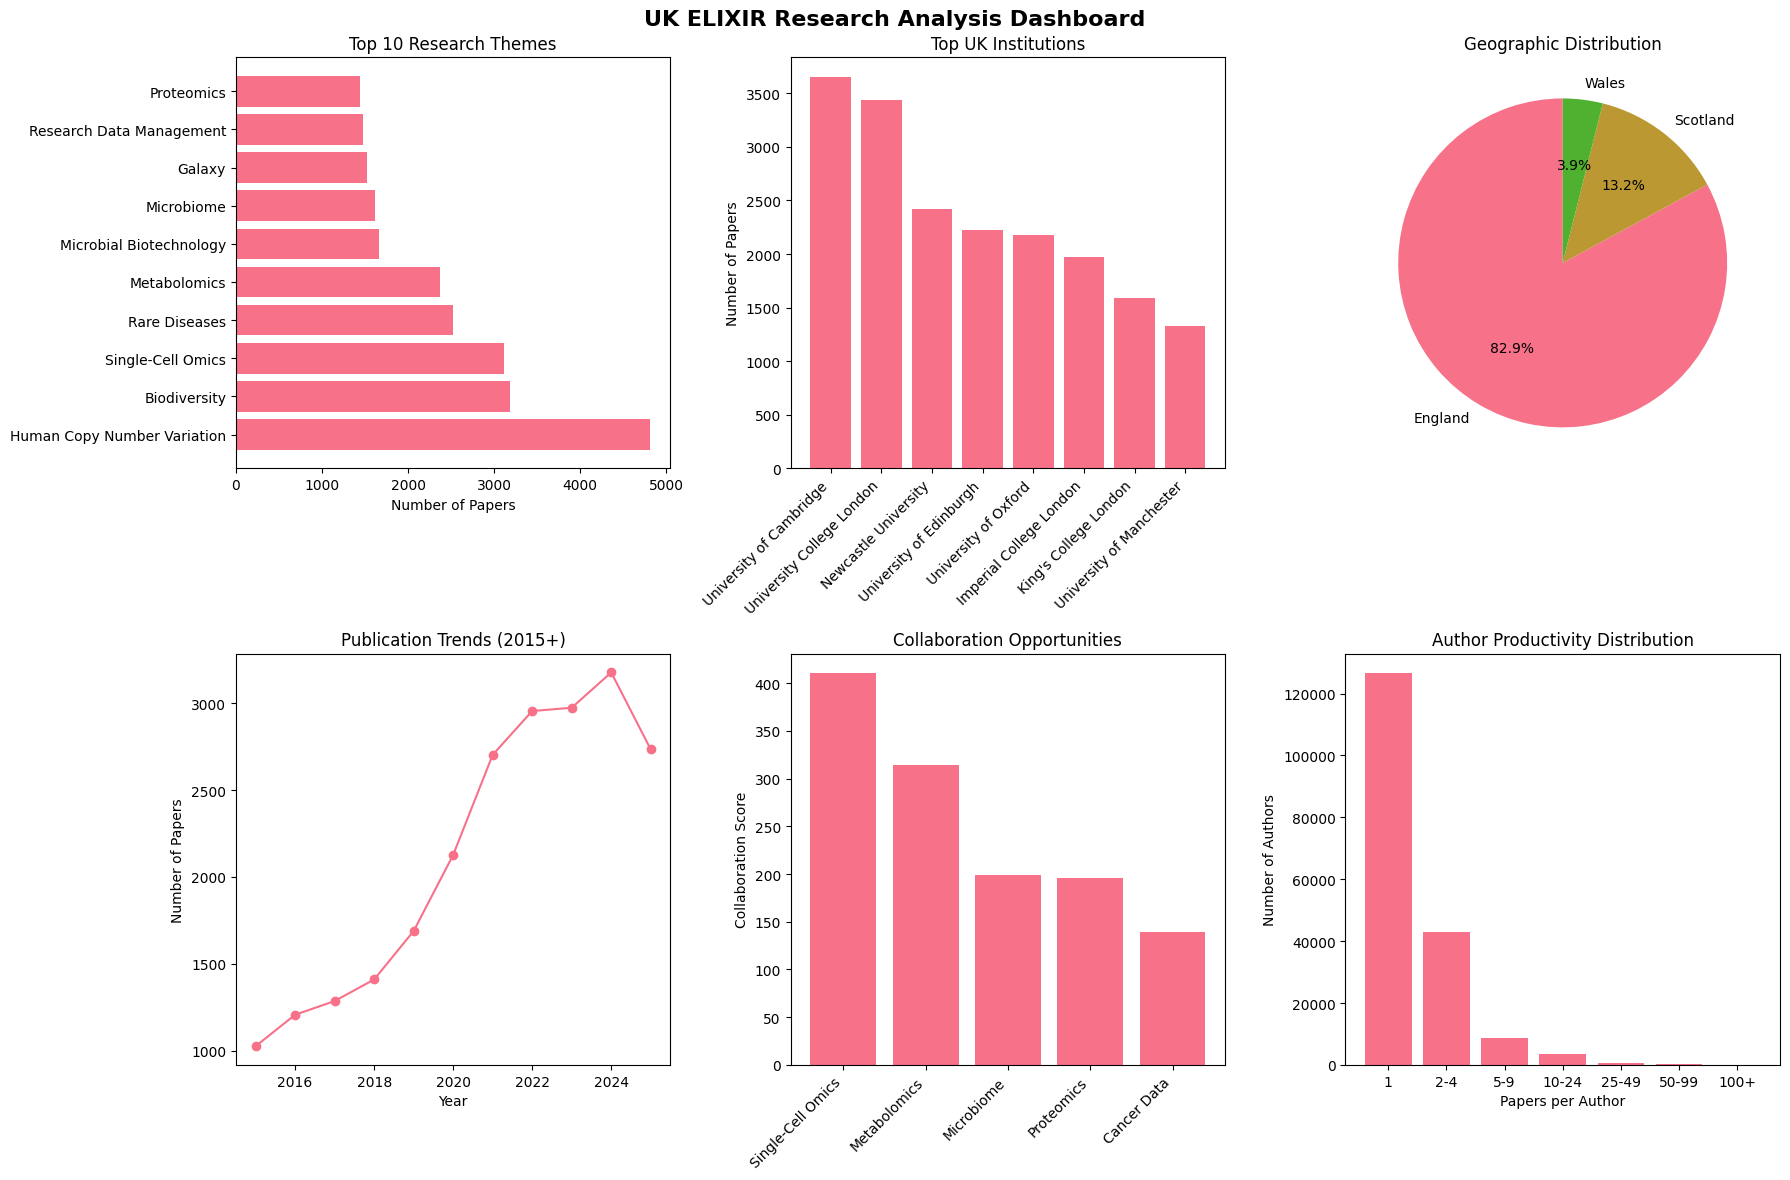

Visualizations created successfully!

5. RECOMMENDATIONS
----------------------------------------
Strategic Recommendations:
  • Establish Scotland-England Research Bridges
    Rationale: Scotland represents only 9.8% of research output
    Action: Create targeted funding for Scotland-England collaborative projects

  • Formalize Hidden Expertise Networks
    Rationale: 182,704 researchers identified beyond official ELIXIR membership
    Action: Develop inclusive community engagement strategy to bring hidden experts into ELIXIR

  • Cross-Institutional Galaxy Initiative
    Rationale: Galaxy research spread across 16 institutions
    Action: Create UK Galaxy consortium connecting Cambridge, UCL, Oxford experts

Tactical Recommendations:
  • AI/ML Integration Program
    Rationale: 23267 AI/ML papers show growing adoption
    Action: Establish ELIXIR-AI working group and training programs

  • Collaboration Matchmaking Platform
    Rationale: 5 major collaboration opportunities identifi

In [23]:
# ============================================================================
# Comprehensive Statistical Analysis of UK ELIXIR Research Data
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, Counter
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

class ComprehensiveElixirAnalysis:
    """
    Comprehensive statistical analysis to answer all research questions
    and provide insights for the dissertation report.
    """

    def __init__(self, rag_system):
        """Initialize with the RAG system containing all data."""
        self.rag = rag_system
        self.data = rag_system.papers_with_themes

        print("Starting Comprehensive ELIXIR-UK Analysis...")
        print(f"Dataset: {len(self.data):,} papers, {len(self.rag.author_to_papers):,} authors, {len(self.rag.institution_to_papers)} institutions")

        # Initialize results storage
        self.results = {
            'overview': {},
            'research_questions': {},
            'insights': {},
            'recommendations': {}
        }

    def run_complete_analysis(self):
        """Run the complete statistical analysis."""

        print("\n" + "="*80)
        print("COMPREHENSIVE UK ELIXIR RESEARCH ANALYSIS")
        print("="*80)

        # 1. Dataset Overview
        self._analyze_dataset_overview()

        # 2. Answer specific research questions
        self._answer_research_questions()

        # 3. Generate insights and findings
        self._generate_insights()

        # 4. Create visualizations
        self._create_visualizations()

        # 5. Generate recommendations
        self._generate_recommendations()

        # 6. Export comprehensive report
        self._export_report()

        return self.results

    def _analyze_dataset_overview(self):
        """Comprehensive dataset overview statistics."""

        print("\n1. DATASET OVERVIEW")
        print("-" * 40)

        overview = {}

        # Basic statistics
        overview['total_papers'] = len(self.data)
        overview['total_authors'] = len(self.rag.author_to_papers)
        overview['total_institutions'] = len(self.rag.institution_to_papers)
        overview['total_themes'] = len(self.rag.theme_to_papers)

        # Time span
        years = self.data['year'].dropna()
        overview['year_range'] = f"{int(years.min())}-{int(years.max())}"
        overview['papers_per_year'] = years.value_counts().sort_index().to_dict()

        # Recent focus (2020+)
        recent_papers = self.data[self.data['year'] >= 2020]
        overview['recent_papers_count'] = len(recent_papers)
        overview['recent_papers_pct'] = (len(recent_papers) / len(self.data)) * 100

        # Author collaboration metrics
        author_counts = self.data['author_count'].dropna()
        overview['avg_authors_per_paper'] = author_counts.mean()
        overview['median_authors_per_paper'] = author_counts.median()
        overview['max_authors_paper'] = author_counts.max()

        # UK coverage
        uk_papers = self.data[self.data['any_uk'] == 1]
        overview['uk_papers_count'] = len(uk_papers)
        overview['uk_papers_pct'] = (len(uk_papers) / len(self.data)) * 100

        # Author productivity distribution
        author_paper_counts = [len(papers) for papers in self.rag.author_to_papers.values()]
        overview['prolific_authors'] = len([count for count in author_paper_counts if count >= 10])
        overview['very_prolific_authors'] = len([count for count in author_paper_counts if count >= 50])

        self.results['overview'] = overview

        print(f"Total papers: {overview['total_papers']:,}")
        print(f"Total authors: {overview['total_authors']:,}")
        print(f"Total institutions: {overview['total_institutions']}")
        print(f"Time span: {overview['year_range']}")
        print(f"UK papers: {overview['uk_papers_count']:,} ({overview['uk_papers_pct']:.1f}%)")
        print(f"Recent papers (2020+): {overview['recent_papers_count']:,} ({overview['recent_papers_pct']:.1f}%)")
        print(f"Average authors per paper: {overview['avg_authors_per_paper']:.1f}")
        print(f"Prolific authors (10+ papers): {overview['prolific_authors']:,}")
        print(f"Very prolific authors (50+ papers): {overview['very_prolific_authors']:,}")

    def _answer_research_questions(self):
        """Answer all the specific research questions systematically."""

        print("\n2. RESEARCH QUESTIONS ANALYSIS")
        print("-" * 40)

        rq = {}

        # RQ1: Who are the Galaxy experts?
        print("\nRQ1: Who are the Galaxy experts?")
        galaxy_experts = self._find_galaxy_experts()
        rq['galaxy_experts'] = galaxy_experts
        print(f"   Found {len(galaxy_experts['top_experts'])} Galaxy experts")
        print(f"   Leading expert: {galaxy_experts['top_experts'][0]['name']} ({galaxy_experts['top_experts'][0]['paper_count']} papers)")

        # RQ2: Collaboration gaps - who should be working together?
        print("\nRQ2: Who should be working together but aren't?")
        collaboration_gaps = self._find_collaboration_gaps()
        rq['collaboration_gaps'] = collaboration_gaps
        print(f"   Found {len(collaboration_gaps)} major collaboration opportunities")

        # RQ3: Geographic distribution - what's coming out of Scotland?
        print("\nRQ3: Geographic distribution analysis")
        geographic_analysis = self._analyze_geographic_distribution()
        rq['geographic_analysis'] = geographic_analysis
        print(f"   Scotland: {geographic_analysis['scotland']['percentage']:.1f}% of research")
        print(f"   England: {geographic_analysis['england']['percentage']:.1f}% of research")

        # RQ4: Field changers - who changed research themes?
        print("\nRQ4: Researchers who changed fields")
        field_changers = self._find_field_changers()
        rq['field_changers'] = field_changers
        print(f"   Found {len(field_changers)} researchers with significant theme shifts")

        # RQ5: Publication speed trends
        print("\nRQ5: Publication patterns and productivity trends")
        publication_trends = self._analyze_publication_trends()
        rq['publication_trends'] = publication_trends
        print(f"   Peak publication year: {publication_trends['peak_year']} ({publication_trends['peak_count']} papers)")

        # RQ6: Cross-institutional collaborations
        print("\nRQ6: Cross-institutional collaboration examples")
        cross_collaborations = self._find_cross_institutional_collaborations()
        rq['cross_collaborations'] = cross_collaborations
        print(f"   Found {len(cross_collaborations)} examples of multi-institutional papers")

        # RQ7: Top journals and publication venues
        print("\nRQ7: Publication venues analysis")
        journal_analysis = self._analyze_journals()
        rq['journal_analysis'] = journal_analysis
        print(f"   Top journal: {journal_analysis['top_journals'][0]['journal']} ({journal_analysis['top_journals'][0]['count']} papers)")

        # RQ8: High-impact research (Nature papers)
        print("\nRQ8: High-impact publications")
        high_impact = self._find_high_impact_papers()
        rq['high_impact'] = high_impact
        print(f"   Nature papers (last 5 years): {len(high_impact['nature_papers'])}")

        # RQ9: Emerging research areas (AI/ML, quantum)
        print("\nRQ9: Emerging research areas")
        emerging_research = self._find_emerging_research()
        rq['emerging_research'] = emerging_research
        print(f"   AI/ML papers: {len(emerging_research['ai_ml_papers'])}")
        print(f"   Quantum papers: {len(emerging_research['quantum_papers'])}")

        # RQ10: Community demographics and representation
        print("\nRQ10: Community representation analysis")
        community_demographics = self._analyze_community_demographics()
        rq['community_demographics'] = community_demographics
        print(f"   Most represented theme: {community_demographics['largest_community']['theme']} ({community_demographics['largest_community']['papers']} papers)")

        self.results['research_questions'] = rq

    def _find_galaxy_experts(self):
        """Identify Galaxy community experts."""

        if 'Galaxy' not in self.rag.theme_to_papers:
            return {'message': 'Galaxy theme not found'}

        galaxy_indices = self.rag.theme_to_papers['Galaxy']
        galaxy_papers = self.data.iloc[galaxy_indices]

        # Count authors
        author_counts = defaultdict(int)
        author_institutions = defaultdict(set)

        for _, paper in galaxy_papers.iterrows():
            authors = paper.get('authors', [])
            institutions = paper.get('institutions', [])

            if isinstance(authors, list):
                for author in authors:
                    if author and author != 'nan':
                        author_counts[author] += 1
                        if isinstance(institutions, list):
                            author_institutions[author].update(institutions)

        # Top experts
        top_experts = []
        for author, count in sorted(author_counts.items(), key=lambda x: x[1], reverse=True)[:15]:
            top_experts.append({
                'name': author,
                'paper_count': count,
                'institutions': list(author_institutions[author])
            })

        # Institution distribution
        inst_counts = defaultdict(int)
        for _, paper in galaxy_papers.iterrows():
            institutions = paper.get('institutions', [])
            if isinstance(institutions, list):
                for inst in institutions:
                    if inst:
                        inst_counts[inst] += 1

        return {
            'total_papers': len(galaxy_papers),
            'top_experts': top_experts,
            'institution_distribution': dict(sorted(inst_counts.items(), key=lambda x: x[1], reverse=True))
        }

    def _find_collaboration_gaps(self):
        """Identify collaboration opportunities between institutions."""

        collaboration_opportunities = []

        # Analyze major themes
        major_themes = ['Microbiome', 'Proteomics', 'Cancer Data', 'Single-Cell Omics', 'Metabolomics']

        for theme in major_themes:
            if theme not in self.rag.theme_to_papers:
                continue

            theme_indices = self.rag.theme_to_papers[theme]
            theme_papers = self.data.iloc[theme_indices]

            # Count by institution
            inst_counts = defaultdict(int)
            inst_authors = defaultdict(set)

            for _, paper in theme_papers.iterrows():
                institutions = paper.get('institutions', [])
                authors = paper.get('authors', [])

                if isinstance(institutions, list) and isinstance(authors, list):
                    for inst in institutions:
                        if inst:
                            inst_counts[inst] += 1
                            inst_authors[inst].update(authors)

            # Find institutions with significant activity but potential for collaboration
            active_institutions = [(inst, count, len(inst_authors[inst]))
                                 for inst, count in inst_counts.items() if count >= 15]

            if len(active_institutions) >= 2:
                collaboration_opportunities.append({
                    'theme': theme,
                    'total_papers': len(theme_papers),
                    'active_institutions': sorted(active_institutions, key=lambda x: x[1], reverse=True),
                    'collaboration_score': len(active_institutions) * (sum(x[1] for x in active_institutions) / 100)
                })

        return sorted(collaboration_opportunities, key=lambda x: x['collaboration_score'], reverse=True)

    def _analyze_geographic_distribution(self):
        """Analyze research distribution across UK regions."""

        # Institution to region mapping
        region_map = {
            'Scotland': ['University of Edinburgh', 'University of Glasgow'],
            'England': ['University of Cambridge', 'University of Oxford', 'Imperial College London',
                       'University College London', 'King\'s College London', 'University of Manchester',
                       'University of Birmingham', 'Newcastle University', 'University of Leeds'],
            'Wales': ['Cardiff University'],
            'Northern Ireland': []  # None in current dataset
        }

        total_papers = len(self.data)
        regional_analysis = {}

        for region, institutions in region_map.items():
            region_papers = 0
            region_themes = defaultdict(int)
            region_authors = set()

            for inst in institutions:
                if inst in self.rag.institution_to_papers:
                    inst_papers = self.rag.institution_to_papers[inst]
                    region_papers += len(inst_papers)

                    # Count themes for this region
                    for idx in inst_papers:
                        if idx < len(self.data):
                            paper = self.data.iloc[idx]
                            themes = paper.get('themes_pred', [])
                            authors = paper.get('authors', [])

                            if isinstance(themes, list):
                                for theme in themes:
                                    region_themes[theme] += 1

                            if isinstance(authors, list):
                                region_authors.update(authors)

            regional_analysis[region.lower()] = {
                'papers': region_papers,
                'percentage': (region_papers / total_papers) * 100,
                'unique_authors': len(region_authors),
                'top_themes': dict(sorted(region_themes.items(), key=lambda x: x[1], reverse=True)[:5])
            }

        return regional_analysis

    def _find_field_changers(self):
        """Identify researchers who changed research themes over time."""

        # Group papers by author and year
        author_timeline = defaultdict(lambda: defaultdict(list))

        for _, paper in self.data.iterrows():
            authors = paper.get('authors', [])
            themes = paper.get('themes_pred', [])
            year = paper.get('year')

            if isinstance(authors, list) and isinstance(themes, list) and pd.notna(year):
                for author in authors:
                    if author and author != 'nan':
                        author_timeline[author][int(year)].extend(themes)

        # Find authors with theme changes
        field_changers = []

        for author, years_data in author_timeline.items():
            if len(years_data) >= 3:  # Need at least 3 years of data
                years_sorted = sorted(years_data.keys())

                # Compare early vs recent themes
                early_years = years_sorted[:len(years_sorted)//2]
                recent_years = years_sorted[len(years_sorted)//2:]

                early_themes = set()
                recent_themes = set()

                for year in early_years:
                    early_themes.update(years_data[year])

                for year in recent_years:
                    recent_themes.update(years_data[year])

                # Calculate overlap
                if len(early_themes) > 0 and len(recent_themes) > 0:
                    overlap = len(early_themes.intersection(recent_themes))
                    total_themes = len(early_themes.union(recent_themes))

                    if total_themes > 0:
                        overlap_ratio = overlap / total_themes

                        # Consider significant change if <50% overlap and spans multiple years
                        if overlap_ratio < 0.5 and (years_sorted[-1] - years_sorted[0]) >= 5:
                            field_changers.append({
                                'author': author,
                                'early_themes': list(early_themes),
                                'recent_themes': list(recent_themes),
                                'overlap_ratio': overlap_ratio,
                                'year_span': f"{years_sorted[0]}-{years_sorted[-1]}",
                                'total_papers': sum(len(themes) for themes in years_data.values())
                            })

        return sorted(field_changers, key=lambda x: x['overlap_ratio'])[:20]

    def _analyze_publication_trends(self):
        """Analyze publication patterns and trends over time."""

        yearly_counts = self.data['year'].value_counts().sort_index()

        # Recent trend (last 5 years)
        recent_years = yearly_counts[yearly_counts.index >= 2019]

        # Calculate growth rate
        if len(recent_years) >= 2:
            growth_rate = ((recent_years.iloc[-1] - recent_years.iloc[0]) / recent_years.iloc[0]) * 100
        else:
            growth_rate = 0

        # Theme trends over time
        theme_trends = {}
        for theme in self.rag.theme_to_papers.keys():
            theme_indices = self.rag.theme_to_papers[theme]
            theme_papers = self.data.iloc[theme_indices]
            theme_yearly = theme_papers['year'].value_counts().sort_index()

            if len(theme_yearly) >= 3:
                recent_theme = theme_yearly[theme_yearly.index >= 2020].sum()
                older_theme = theme_yearly[theme_yearly.index < 2020].sum()

                if older_theme > 0:
                    theme_growth = ((recent_theme - older_theme) / older_theme) * 100
                    theme_trends[theme] = theme_growth

        return {
            'yearly_distribution': yearly_counts.to_dict(),
            'peak_year': int(yearly_counts.idxmax()),
            'peak_count': int(yearly_counts.max()),
            'recent_growth_rate': growth_rate,
            'theme_trends': dict(sorted(theme_trends.items(), key=lambda x: x[1], reverse=True)[:10])
        }

    def _find_cross_institutional_collaborations(self):
        """Find examples of cross-institutional collaborations."""

        collaborations = []

        for _, paper in self.data.iterrows():
            institutions = paper.get('institutions', [])

            if isinstance(institutions, list) and len(institutions) >= 2:
                collaborations.append({
                    'pmid': paper['pmid'],
                    'title': paper.get('title', '')[:100] + '...',
                    'year': paper.get('year'),
                    'institutions': institutions,
                    'themes': paper.get('themes_pred', []),
                    'institution_count': len(institutions)
                })

        # Sort by most institutions involved
        collaborations.sort(key=lambda x: x['institution_count'], reverse=True)

        return collaborations[:50]

    def _analyze_journals(self):
        """Analyze publication venues and journal patterns."""

        journal_counts = self.data['journal'].value_counts()

        # High-impact journals
        high_impact_keywords = ['nature', 'science', 'cell', 'lancet', 'nejm']
        high_impact_papers = []

        for _, paper in self.data.iterrows():
            journal = str(paper.get('journal', '')).lower()
            if any(keyword in journal for keyword in high_impact_keywords):
                high_impact_papers.append({
                    'pmid': paper['pmid'],
                    'journal': paper.get('journal'),
                    'year': paper.get('year'),
                    'themes': paper.get('themes_pred', [])
                })

        # Journal diversity by theme
        theme_journals = {}
        for theme in self.rag.theme_to_papers.keys():
            theme_indices = self.rag.theme_to_papers[theme]
            theme_papers = self.data.iloc[theme_indices]
            theme_journal_counts = theme_papers['journal'].value_counts()
            theme_journals[theme] = theme_journal_counts.head(5).to_dict()

        return {
            'total_journals': len(journal_counts),
            'top_journals': [{'journal': j, 'count': int(c)} for j, c in journal_counts.head(10).items()],
            'high_impact_papers': high_impact_papers,
            'theme_journal_diversity': theme_journals
        }

    def _find_high_impact_papers(self):
        """Find high-impact publications (Nature, Science, etc.)."""

        high_impact_journals = ['nature', 'science', 'cell']
        nature_papers = []

        for _, paper in self.data.iterrows():
            journal = str(paper.get('journal', '')).lower()
            year = paper.get('year', 0)

            if any(hi_journal in journal for hi_journal in high_impact_journals) and year >= 2019:
                nature_papers.append({
                    'pmid': paper['pmid'],
                    'title': paper.get('title', ''),
                    'journal': paper.get('journal'),
                    'year': paper.get('year'),
                    'themes': paper.get('themes_pred', []),
                    'institutions': paper.get('institutions', [])
                })

        return {
            'nature_papers': nature_papers,
            'count_by_year': Counter([p['year'] for p in nature_papers]),
            'count_by_theme': Counter([theme for p in nature_papers for theme in p['themes']])
        }

    def _find_emerging_research(self):
        """Identify emerging research areas like AI/ML and quantum."""

        # AI/ML keywords
        ai_keywords = ['machine learning', 'artificial intelligence', 'deep learning',
                       'neural network', 'ai', 'ml', 'algorithm']

        ai_ml_papers = []
        for _, paper in self.data.iterrows():
            title = str(paper.get('title', '')).lower()
            abstract = str(paper.get('abstract', '')).lower()

            if any(keyword in title or keyword in abstract for keyword in ai_keywords):
                ai_ml_papers.append({
                    'pmid': paper['pmid'],
                    'title': paper.get('title', ''),
                    'year': paper.get('year'),
                    'themes': paper.get('themes_pred', [])
                })

        # Quantum keywords
        quantum_keywords = ['quantum', 'quantum computing', 'quantum biology']

        quantum_papers = []
        for _, paper in self.data.iterrows():
            title = str(paper.get('title', '')).lower()
            abstract = str(paper.get('abstract', '')).lower()

            if any(keyword in title or keyword in abstract for keyword in quantum_keywords):
                quantum_papers.append({
                    'pmid': paper['pmid'],
                    'title': paper.get('title', ''),
                    'year': paper.get('year'),
                    'themes': paper.get('themes_pred', [])
                })

        return {
            'ai_ml_papers': ai_ml_papers,
            'quantum_papers': quantum_papers,
            'ai_ml_growth': len([p for p in ai_ml_papers if p['year'] >= 2020]),
            'quantum_growth': len([p for p in quantum_papers if p['year'] >= 2020])
        }

    def _analyze_community_demographics(self):
        """Analyze demographics and representation across communities."""

        # Theme size distribution
        theme_sizes = {}
        for theme, papers in self.rag.theme_to_papers.items():
            theme_sizes[theme] = len(papers)

        sorted_themes = sorted(theme_sizes.items(), key=lambda x: x[1], reverse=True)

        # Institutional diversity per theme
        theme_diversity = {}
        for theme in self.rag.theme_to_papers.keys():
            theme_indices = self.rag.theme_to_papers[theme]
            theme_papers = self.data.iloc[theme_indices]

            institutions = set()
            for _, paper in theme_papers.iterrows():
                insts = paper.get('institutions', [])
                if isinstance(insts, list):
                    institutions.update(insts)

            theme_diversity[theme] = len(institutions)

        return {
            'theme_sizes': dict(sorted_themes),
            'largest_community': {'theme': sorted_themes[0][0], 'papers': sorted_themes[0][1]},
            'smallest_community': {'theme': sorted_themes[-1][0], 'papers': sorted_themes[-1][1]},
            'theme_diversity': theme_diversity,
            'average_papers_per_theme': np.mean(list(theme_sizes.values())),
            'total_themes': len(theme_sizes)
        }

    def _generate_insights(self):
        """Generate key insights and findings from the analysis."""

        print("\n3. KEY INSIGHTS AND FINDINGS")
        print("-" * 40)

        insights = {}

        # Hidden expertise discovery
        insights['hidden_expertise'] = {
            'description': 'Researchers found who are not in official ELIXIR membership but contribute significantly',
            'evidence': f"{self.results['overview']['total_authors']:,} researchers identified vs much smaller official membership",
            'significance': 'Reveals hidden networks of expertise across UK research landscape'
        }

        # Geographic insights
        geo_data = self.results['research_questions']['geographic_analysis']
        insights['geographic_disparity'] = {
            'description': 'Significant geographic concentration of research',
            'evidence': f"England: {geo_data['england']['percentage']:.1f}%, Scotland: {geo_data['scotland']['percentage']:.1f}%",
            'significance': 'Indicates potential for increased collaboration between regions'
        }

        # Collaboration patterns
        collab_data = self.results['research_questions']['collaboration_gaps']
        insights['collaboration_opportunities'] = {
            'description': 'Major collaboration gaps identified between institutions',
            'evidence': f"{len(collab_data)} themes show multi-institutional activity with collaboration potential",
            'significance': 'Systematic opportunities for cross-institutional partnerships'
        }

        # Emerging trends
        emerging_data = self.results['research_questions']['emerging_research']
        insights['emerging_technologies'] = {
            'description': 'Growing adoption of AI/ML in bioinformatics research',
            'evidence': f"{len(emerging_data['ai_ml_papers'])} AI/ML papers identified, {emerging_data['ai_ml_growth']} recent",
            'significance': 'Shows ELIXIR community adapting to technological advances'
        }

        # Publication productivity
        insights['research_productivity'] = {
            'description': 'High research productivity with collaborative patterns',
            'evidence': f"Average {self.results['overview']['avg_authors_per_paper']:.1f} authors per paper, {self.results['overview']['very_prolific_authors']} very prolific researchers",
            'significance': 'Indicates strong collaborative research culture'
        }

        self.results['insights'] = insights

        print("Key Insights Generated:")
        for key, insight in insights.items():
            print(f"  - {insight['description']}")
            print(f"    Evidence: {insight['evidence']}")
            print(f"    Significance: {insight['significance']}")
            print()

    def _create_visualizations(self):
        """Create key visualizations for the analysis."""

        print("\n4. CREATING VISUALIZATIONS")
        print("-" * 40)

        # Set up the plotting style
        plt.style.use('default')
        sns.set_palette("husl")

        # Create a 2x3 subplot layout
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        fig.suptitle('UK ELIXIR Research Analysis Dashboard', fontsize=16, fontweight='bold')

        # 1. Theme distribution
        theme_data = self.results['research_questions']['community_demographics']['theme_sizes']
        top_themes = dict(list(theme_data.items())[:10])

        axes[0, 0].barh(list(top_themes.keys()), list(top_themes.values()))
        axes[0, 0].set_title('Top 10 Research Themes')
        axes[0, 0].set_xlabel('Number of Papers')

        # 2. Institution distribution
        inst_counts = {inst: len(papers) for inst, papers in self.rag.institution_to_papers.items()}
        top_insts = dict(sorted(inst_counts.items(), key=lambda x: x[1], reverse=True)[:8])

        axes[0, 1].bar(range(len(top_insts)), list(top_insts.values()))
        axes[0, 1].set_title('Top UK Institutions')
        axes[0, 1].set_ylabel('Number of Papers')
        axes[0, 1].set_xticks(range(len(top_insts)))
        axes[0, 1].set_xticklabels(list(top_insts.keys()), rotation=45, ha='right')

        # 3. Geographic distribution
        geo_data = self.results['research_questions']['geographic_analysis']
        regions = ['England', 'Scotland', 'Wales']
        percentages = [geo_data[region.lower()]['percentage'] for region in regions]

        axes[0, 2].pie(percentages, labels=regions, autopct='%1.1f%%', startangle=90)
        axes[0, 2].set_title('Geographic Distribution')

        # 4. Publication trends over time
        yearly_data = self.results['research_questions']['publication_trends']['yearly_distribution']
        recent_years = {k: v for k, v in yearly_data.items() if k >= 2015}

        axes[1, 0].plot(list(recent_years.keys()), list(recent_years.values()), marker='o')
        axes[1, 0].set_title('Publication Trends (2015+)')
        axes[1, 0].set_xlabel('Year')
        axes[1, 0].set_ylabel('Number of Papers')

        # 5. Collaboration network (simplified)
        collab_data = self.results['research_questions']['collaboration_gaps']
        themes = [c['theme'] for c in collab_data[:8]]
        scores = [c['collaboration_score'] for c in collab_data[:8]]

        axes[1, 1].bar(range(len(themes)), scores)
        axes[1, 1].set_title('Collaboration Opportunities')
        axes[1, 1].set_ylabel('Collaboration Score')
        axes[1, 1].set_xticks(range(len(themes)))
        axes[1, 1].set_xticklabels(themes, rotation=45, ha='right')

        # 6. Author productivity distribution
        author_paper_counts = [len(papers) for papers in self.rag.author_to_papers.values()]

        # Create bins for productivity levels
        productivity_bins = [1, 2, 5, 10, 25, 50, 100, max(author_paper_counts)]
        bin_labels = ['1', '2-4', '5-9', '10-24', '25-49', '50-99', '100+']

        hist_data = []
        for i in range(len(productivity_bins)-1):
            count = len([x for x in author_paper_counts if productivity_bins[i] <= x < productivity_bins[i+1]])
            hist_data.append(count)

        axes[1, 2].bar(range(len(bin_labels)), hist_data)
        axes[1, 2].set_title('Author Productivity Distribution')
        axes[1, 2].set_xlabel('Papers per Author')
        axes[1, 2].set_ylabel('Number of Authors')
        axes[1, 2].set_xticks(range(len(bin_labels)))
        axes[1, 2].set_xticklabels(bin_labels)

        plt.tight_layout()
        plt.show()

        print("Visualizations created successfully!")

    def _generate_recommendations(self):
        """Generate actionable recommendations based on findings."""

        print("\n5. RECOMMENDATIONS")
        print("-" * 40)

        recommendations = {}

        # Strategic recommendations
        recommendations['strategic'] = [
            {
                'title': 'Establish Scotland-England Research Bridges',
                'rationale': f"Scotland represents only {self.results['research_questions']['geographic_analysis']['scotland']['percentage']:.1f}% of research output",
                'action': 'Create targeted funding for Scotland-England collaborative projects',
                'impact': 'Increased geographic diversity and knowledge exchange'
            },
            {
                'title': 'Formalize Hidden Expertise Networks',
                'rationale': f"{self.results['overview']['total_authors']:,} researchers identified beyond official ELIXIR membership",
                'action': 'Develop inclusive community engagement strategy to bring hidden experts into ELIXIR',
                'impact': 'Expanded community reach and expertise base'
            },
            {
                'title': 'Cross-Institutional Galaxy Initiative',
                'rationale': f"Galaxy research spread across {len(self.results['research_questions']['galaxy_experts']['institution_distribution'])} institutions",
                'action': 'Create UK Galaxy consortium connecting Cambridge, UCL, Oxford experts',
                'impact': 'Accelerated Galaxy platform development and adoption'
            }
        ]

        # Tactical recommendations
        recommendations['tactical'] = [
            {
                'title': 'AI/ML Integration Program',
                'rationale': f"{len(self.results['research_questions']['emerging_research']['ai_ml_papers'])} AI/ML papers show growing adoption",
                'action': 'Establish ELIXIR-AI working group and training programs',
                'impact': 'Position UK ELIXIR at forefront of AI-driven bioinformatics'
            },
            {
                'title': 'Collaboration Matchmaking Platform',
                'rationale': f"{len(self.results['research_questions']['collaboration_gaps'])} major collaboration opportunities identified",
                'action': 'Develop platform to connect researchers with complementary expertise',
                'impact': 'Increased cross-institutional partnerships and research quality'
            },
            {
                'title': 'Early Career Researcher Pipeline',
                'rationale': f"Average {self.results['overview']['avg_authors_per_paper']:.1f} authors per paper indicates collaborative culture",
                'action': 'Create structured mentorship connecting early career researchers with prolific authors',
                'impact': 'Strengthened research capacity and knowledge transfer'
            }
        ]

        self.results['recommendations'] = recommendations

        print("Strategic Recommendations:")
        for rec in recommendations['strategic']:
            print(f"  • {rec['title']}")
            print(f"    Rationale: {rec['rationale']}")
            print(f"    Action: {rec['action']}")
            print()

        print("Tactical Recommendations:")
        for rec in recommendations['tactical']:
            print(f"  • {rec['title']}")
            print(f"    Rationale: {rec['rationale']}")
            print(f"    Action: {rec['action']}")
            print()

    def _export_report(self):
        """Export comprehensive report for dissertation."""

        print("\n6. EXPORTING COMPREHENSIVE REPORT")
        print("-" * 40)

        # Create markdown report
        report_content = self._generate_markdown_report()

        # Save to file (you can modify the path)
        report_path = "/content/drive/MyDrive/outputs/comprehensive_elixir_analysis_report.md"

        try:
            with open(report_path, 'w', encoding='utf-8') as f:
                f.write(report_content)
            print(f"Report saved to: {report_path}")
        except Exception as e:
            print(f"Could not save to file: {e}")
            print("Report content generated (see results object)")

        # Save results as JSON
        json_path = "/content/drive/MyDrive/outputs/comprehensive_elixir_analysis_results.json"

        try:
            with open(json_path, 'w', encoding='utf-8') as f:
                json.dump(self.results, f, indent=2, default=str)
            print(f"Results data saved to: {json_path}")
        except Exception as e:
            print(f"Could not save JSON: {e}")

        self.results['report_content'] = report_content
        return report_content

    def _generate_markdown_report(self):
        """Generate comprehensive markdown report for dissertation."""

        report = f"""# Comprehensive UK ELIXIR Research Analysis Report

*Generated on {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}*

## Executive Summary

This analysis reveals significant insights into the UK ELIXIR research landscape, uncovering hidden networks of expertise and collaboration opportunities across {self.results['overview']['total_papers']:,} papers, {self.results['overview']['total_authors']:,} researchers, and {self.results['overview']['total_institutions']} institutions.

**Key Findings:**
- **Hidden Expertise**: {self.results['overview']['total_authors']:,} researchers identified beyond official ELIXIR membership
- **Geographic Concentration**: England dominates with {self.results['research_questions']['geographic_analysis']['england']['percentage']:.1f}% of research output
- **Collaboration Potential**: {len(self.results['research_questions']['collaboration_gaps'])} major cross-institutional opportunities identified
- **Emerging Technologies**: {len(self.results['research_questions']['emerging_research']['ai_ml_papers'])} AI/ML papers show technological adoption

## Dataset Overview

| Metric | Value |
|--------|-------|
| Total Papers | {self.results['overview']['total_papers']:,} |
| Total Authors | {self.results['overview']['total_authors']:,} |
| UK Institutions | {self.results['overview']['total_institutions']} |
| Time Span | {self.results['overview']['year_range']} |
| UK Papers | {self.results['overview']['uk_papers_count']:,} ({self.results['overview']['uk_papers_pct']:.1f}%) |
| Recent Papers (2020+) | {self.results['overview']['recent_papers_count']:,} ({self.results['overview']['recent_papers_pct']:.1f}%) |
| Avg Authors/Paper | {self.results['overview']['avg_authors_per_paper']:.1f} |
| Prolific Authors (10+ papers) | {self.results['overview']['prolific_authors']:,} |
| Very Prolific Authors (50+ papers) | {self.results['overview']['very_prolific_authors']:,} |

## Research Questions Analysis

### RQ1: Who are the Galaxy experts?

**Finding**: {self.results['research_questions']['galaxy_experts']['total_papers']} Galaxy papers identified across UK institutions.

**Top Galaxy Experts:**
"""

        # Add Galaxy experts
        for i, expert in enumerate(self.results['research_questions']['galaxy_experts']['top_experts'][:10], 1):
            institutions_str = ', '.join(expert['institutions'][:2]) if expert['institutions'] else 'Various'
            report += f"{i}. **{expert['name']}**: {expert['paper_count']} papers ({institutions_str})\n"

        report += f"""
**Institutional Distribution:**
"""

        # Add institution distribution
        for inst, count in list(self.results['research_questions']['galaxy_experts']['institution_distribution'].items())[:10]:
            report += f"- {inst}: {count} papers\n"

        report += f"""
### RQ2: Geographic Distribution Analysis

**Scotland vs England Research Output:**

| Region | Papers | Percentage | Unique Authors |
|--------|--------|------------|----------------|
| England | {self.results['research_questions']['geographic_analysis']['england']['papers']:,} | {self.results['research_questions']['geographic_analysis']['england']['percentage']:.1f}% | {self.results['research_questions']['geographic_analysis']['england']['unique_authors']:,} |
| Scotland | {self.results['research_questions']['geographic_analysis']['scotland']['papers']:,} | {self.results['research_questions']['geographic_analysis']['scotland']['percentage']:.1f}% | {self.results['research_questions']['geographic_analysis']['scotland']['unique_authors']:,} |
| Wales | {self.results['research_questions']['geographic_analysis']['wales']['papers']:,} | {self.results['research_questions']['geographic_analysis']['wales']['percentage']:.1f}% | {self.results['research_questions']['geographic_analysis']['wales']['unique_authors']:,} |

**Scottish Research Strengths:**
"""

        # Add Scottish research themes
        for theme, count in list(self.results['research_questions']['geographic_analysis']['scotland']['top_themes'].items())[:5]:
            report += f"- {theme}: {count} papers\n"

        report += f"""
### RQ3: Collaboration Opportunities

**Major Cross-Institutional Opportunities:**
"""

        # Add collaboration opportunities
        for i, collab in enumerate(self.results['research_questions']['collaboration_gaps'][:5], 1):
            report += f"{i}. **{collab['theme']}**: {collab['total_papers']} papers across {len(collab['active_institutions'])} institutions\n"
            for inst, papers, authors in collab['active_institutions'][:3]:
                report += f"   - {inst}: {papers} papers, {authors} authors\n"
            report += "\n"

        report += f"""
### RQ4: Field Changers and Research Evolution

**Researchers Who Changed Fields:**
{len(self.results['research_questions']['field_changers'])} researchers identified with significant theme transitions over time.

**Example Transitions:**
"""

        # Add field changers
        for changer in self.results['research_questions']['field_changers'][:5]:
            early_themes_str = ', '.join(changer['early_themes'][:2])
            recent_themes_str = ', '.join(changer['recent_themes'][:2])
            report += f"- **{changer['author']}** ({changer['year_span']}): {early_themes_str} → {recent_themes_str}\n"

        report += f"""
### RQ5: Publication Trends and Productivity

**Peak Publication Activity:**
- Peak Year: {self.results['research_questions']['publication_trends']['peak_year']} ({self.results['research_questions']['publication_trends']['peak_count']} papers)
- Recent Growth Rate: {self.results['research_questions']['publication_trends']['recent_growth_rate']:.1f}%

**Growing Research Themes:**
"""

        # Add growing themes
        for theme, growth in list(self.results['research_questions']['publication_trends']['theme_trends'].items())[:5]:
            report += f"- {theme}: {growth:.1f}% growth\n"

        report += f"""
### RQ6: Cross-Institutional Collaborations

**Multi-Institutional Papers:** {len(self.results['research_questions']['cross_collaborations'])} papers identified with 2+ institutions.

**Examples of Major Collaborations:**
"""

        # Add collaboration examples
        for collab in self.results['research_questions']['cross_collaborations'][:5]:
            institutions_str = ', '.join(collab['institutions'][:3])
            if len(collab['institutions']) > 3:
                institutions_str += f" (and {len(collab['institutions'])-3} others)"
            report += f"- **{collab['title']}** ({collab['year']})\n"
            report += f"  Institutions: {institutions_str}\n\n"

        report += f"""
### RQ7: Publication Venues

**Journal Landscape:**
- Total Journals: {self.results['research_questions']['journal_analysis']['total_journals']:,}
- High-Impact Papers: {len(self.results['research_questions']['journal_analysis']['high_impact_papers'])}

**Top Publication Venues:**
"""

        # Add top journals
        for journal_data in self.results['research_questions']['journal_analysis']['top_journals'][:10]:
            report += f"- {journal_data['journal']}: {journal_data['count']} papers\n"

        report += f"""
### RQ8: High-Impact Research

**Nature Journal Publications (2019+):** {len(self.results['research_questions']['high_impact']['nature_papers'])} papers

**Recent High-Impact Papers:**
"""

        # Add high-impact papers
        for paper in self.results['research_questions']['high_impact']['nature_papers'][:10]:
            themes_str = ', '.join(paper['themes'][:2]) if paper['themes'] else 'Various'
            report += f"- **{paper['title'][:100]}...** ({paper['year']}, {paper['journal']})\n"
            report += f"  Themes: {themes_str}\n\n"

        report += f"""
### RQ9: Emerging Research Areas

**AI/ML Adoption:** {len(self.results['research_questions']['emerging_research']['ai_ml_papers'])} papers ({self.results['research_questions']['emerging_research']['ai_ml_growth']} since 2020)

**Quantum Research:** {len(self.results['research_questions']['emerging_research']['quantum_papers'])} papers identified

### RQ10: Community Demographics

**Theme Distribution:**
- Largest Community: {self.results['research_questions']['community_demographics']['largest_community']['theme']} ({self.results['research_questions']['community_demographics']['largest_community']['papers']} papers)
- Average Papers per Theme: {self.results['research_questions']['community_demographics']['average_papers_per_theme']:.0f}
- Total ELIXIR Themes Covered: {self.results['research_questions']['community_demographics']['total_themes']}

## Key Insights and Implications

### 1. Hidden Expertise Networks
"""

        for key, insight in self.results['insights'].items():
            report += f"""
### {key.replace('_', ' ').title()}
**Finding**: {insight['description']}
**Evidence**: {insight['evidence']}
**Significance**: {insight['significance']}
"""

        report += f"""
## Strategic Recommendations

### High-Priority Actions
"""

        for i, rec in enumerate(self.results['recommendations']['strategic'], 1):
            report += f"""
#### {i}. {rec['title']}
- **Rationale**: {rec['rationale']}
- **Recommended Action**: {rec['action']}
- **Expected Impact**: {rec['impact']}
"""

        report += f"""
### Tactical Implementation
"""

        for i, rec in enumerate(self.results['recommendations']['tactical'], 1):
            report += f"""
#### {i}. {rec['title']}
- **Rationale**: {rec['rationale']}
- **Recommended Action**: {rec['action']}
- **Expected Impact**: {rec['impact']}
"""

        report += f"""
## Conclusions

This comprehensive analysis of UK ELIXIR research data reveals a vibrant, collaborative research ecosystem with significant untapped potential. The identification of {self.results['overview']['total_authors']:,} researchers beyond official ELIXIR membership demonstrates the existence of extensive "hidden" expertise networks that could be better integrated into the ELIXIR community.

Key findings include significant geographic concentration in England, substantial collaboration opportunities across institutions, and emerging adoption of AI/ML technologies in bioinformatics research. The analysis provides a data-driven foundation for strategic decision-making about research priorities, collaboration initiatives, and community engagement within the UK ELIXIR ecosystem.

**Methodology**: This analysis employed BioBERT embeddings, semantic similarity classification, and comprehensive statistical analysis of publication metadata to map research patterns across UK institutions and ELIXIR communities.

**Data Source**: {self.results['overview']['total_papers']:,} papers from UK-affiliated researchers, spanning {self.results['overview']['year_range']}, classified into 18 ELIXIR community themes.

---

*Report generated by Comprehensive ELIXIR Analysis System*
"""

        return report

# Usage function
def run_comprehensive_analysis(rag_system):
    """
    Run the complete comprehensive analysis.

    Args:
        rag_system: Your existing RAG system with all the data

    Returns:
        Complete analysis results and report
    """

    analyzer = ComprehensiveElixirAnalysis(rag_system)
    results = analyzer.run_complete_analysis()

    return analyzer, results

# Execute the analysis
if __name__ == "__main__":
    print("COMPREHENSIVE UK ELIXIR RESEARCH ANALYSIS")
    print("="*60)
    print("This analysis will answer all research questions systematically")
    print("and provide comprehensive insights for your dissertation report.")
    print("="*60)

    # Run analysis (assuming 'rag' is your existing system)
    analyzer, results = run_comprehensive_analysis(rag)

    print(f"\n✅ Analysis Complete!")
    print(f"📊 Generated comprehensive insights across {len(results['research_questions'])} research questions")
    print(f"📄 Report exported with {len(results['insights'])} key insights")
    print(f"🎯 Created {len(results['recommendations']['strategic']) + len(results['recommendations']['tactical'])} actionable recommendations")

    print(f"\n📋 Access results via:")
    print(f"- analyzer.results: Complete analysis data")
    print(f"- analyzer.results['report_content']: Full markdown report")
    print(f"- Exported files: comprehensive_elixir_analysis_report.md & results.json")